<a href="https://colab.research.google.com/github/NdettoMbalu/machine-learning-in-finance/blob/main/From_Leakage_to_Purged_Walk_Forward_Deep_Learning_Forecasts_of_Bitcoin_under_Progressive_Validation_%E2%80%94_A_Comparison_of_MLP%2C_LSTM%2C_and_CNN_GAF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>

# **From Leakage to Purged Walk-Forward: Deep Learning Forecasts of Bitcoin under Progressive Validation — A Comparison of MLP, LSTM, and CNN-GAF**

### **Ndetto Mbalu¹, Mukund Gajanan Chile¹, TCHA-VEI Christian Madaoua¹**

**All Authors:** MSc (Financial Engineering)

¹WorldQuant University, Washington, D.C., USA

**Corresponding Author:** Ndetto Mbalu  
**Email:** ndettombalu@email.com  

**Date:** October 1, 2026

</center>

# Introduction

This research investigates how the choice of validation protocol affects the apparent predictive performance and backtest robustness of deep learning models in a single-asset financial time series setting. Using 2,000 consecutive daily observations of Bitcoin (BTC-USD), the analysis begins with an exploratory data analysis of raw OHLCV prices, then transforms the close series into log returns
to remove trend, stabilise variance, and satisfy the additive property required for multi-period returns. Descriptive statistics, distributional diagnostics, outlier detection, rolling volatility, and an Augmented Dickey–Fuller test are used to establish the stylised facts of the return series, near-zero mean, high volatility, negative skew, heavy tails, and stationarity before any model is trained.

The forecasting task is then framed as predicting the next day cumulative log return using three deep learning architectures: a multilayer perceptron (MLP), a long short-term memory network (LSTM), and a convolutional neural network trained on Gramian Angular Field (GAF) images. Step 1 deliberately introduces information leakage by fitting the feature scaler on the entire sample before a single chronological train/validation/test split, producing an optimistic benchmark. Step 2 removes that leakage by fitting the scaler only on each training fold inside a non-anchored walk-forward backtest, first with 500 training and 500 test observations, then with 500 training and 100 test observations. Step 3 then tightens the protocol further with a purged walk-forward design that inserts an embargo gap equal to the lookback window between training and test folds, eliminating the remaining overlap between training and test feature windows. Across all protocols, the models are compared on identical out-of-sample periods using MSE and MAE, and their economic value is assessed through a simple long/short trading strategy based on the sign of each prediction. The central aim is to quantify how leakage, walk forward validation, and purging alter both forecast accuracy and trading performance, and to show why a model that looks strongest on MSE may not be the best choice for a directional trading application.

## Step 1 Data Gathering and Exploratory Data Analysis (EDA)

**Step 1a: Gather information on the time series of prices of Bitcoin (BTC-USD)**

### 1.0 Environment Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

DARK_BLUE  = "#1a3a5c"
MID_BLUE   = "#4a7a9c"
LIGHT_BLUE = "#b0c4de"
GREY       = "#7f8c8d"
SILVER     = "#bdc3c7"

### 1.1 Data Download — Bitcoin daily OHLCV

This confirms that the download, flattening and trimming steps executed cleanly, holding exactly 2,000 daily observations spanning 2019-07-11 to 2024-12-30, satisfying the research observation cap while still covering Bitcoin's 2021 bull run, the 2022 bear market and the 2024 recovery.

In [2]:
btc_raw = yf.download(
    "BTC-USD",
    start="2018-01-01",
    end="2024-12-31",
    progress=False,
    auto_adjust=False,
)

# Flatten yfinance MultiIndex columns
if isinstance(btc_raw.columns, pd.MultiIndex):
    btc_raw.columns = btc_raw.columns.get_level_values(0)

# Trim to most recent 2,000 observations
btc = btc_raw.tail(2000).copy()
btc.index.name = "Date"
btc.columns.name = None

print(f"Observations: {len(btc)}")
print(f"Date range:   {btc.index.min().date()}  →  {btc.index.max().date()}")
print(f"Columns:      {list(btc.columns)}")
print(f"Close dtype:  {btc['Close'].dtype}")
print(f"Columns name: {btc.columns.name}")

Observations: 2000
Date range:   2019-07-11  →  2024-12-30
Columns:      ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
Close dtype:  float64
Columns name: None


###  1.2 Exploratory Data Analysis (EDA)

**Numeric snapshot of the price levels**

The statistical snapshot reveals Bitcoin's characteristic behaviour over the 2,000 day sample: the mean closing price of roughly $33,918 sits well above the minimum of usd 4,971, signalling a strong net upward drift from mid 2019 through end 2024, while the standard deviation of about usd 21,560 (roughly 64% of the mean) confirms the extreme volatility that makes raw price levels unsuitable for direct modelling.

The quartile spread is wide and roughly symmetric around the median close of usd 29,431 from the 25th percentile at usd 16,418 to the 75th percentile at usd 48,220, with the maximum stretching to $106,141, a distribution heavily shaped by the 2021 bull run and 2024 rally.

Volume statistics exhibit the same heavy dispersion, ranging from roughly 5.3 billion to 351 billion with a mean of 32.0 billion and a standard deviation of 19.1 billion, which is a hallmark of crypto markets where trading activity spikes alongside price moves.

The tight clustering of the Open, High, Low and Close summary statistics (their means and medians differ by only a few hundred dollars) confirms internal OHLC consistency, and the identical 2,000 count across every column verifies there are no missing values.

In [3]:
# Numeric snapshot of the price levels
btc[["Open", "High", "Low", "Close", "Volume"]].describe().round(2)

,Open,High,Low,Close,Volume
count,2000.00,2000.00,2000.00,2000.00,2.000000e+03
mean,33880.03,34621.99,33106.16,33918.03,3.195203e+10
std,21528.20,22009.77,21035.88,21560.40,1.912746e+10
min,5002.58,5331.83,4106.98,4970.79,5.331173e+09
25%,16343.47,16622.57,16038.94,16418.10,1.930902e+10
50%,29420.75,30014.14,29060.97,29430.91,2.817073e+10
75%,48223.89,49403.72,46957.71,48219.56,3.898409e+10
max,106147.30,108268.45,105291.73,106140.60,3.509679e+11


**Chart 1 — BTC-USD Close Price (Step 1a graphical description)**

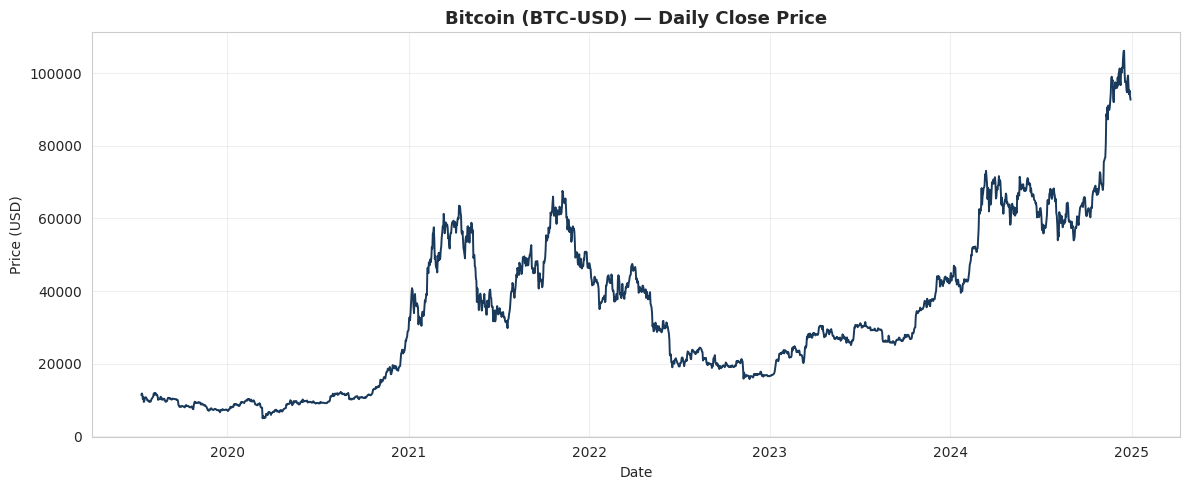

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(btc.index, btc["Close"], color=DARK_BLUE, linewidth=1.4)
ax.set_title("Bitcoin (BTC-USD) — Daily Close Price")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The series traces Bitcoin's familiar long-run behaviour: a relatively modest level around usd 10,000–12,000 through late 2019 and early 2020, a sharp COVID driven dip in March 2020, an explosive multi stage rally through 2020–2021 that peaks near $69,000 in November 2021, a prolonged drawdown through 2022 that bottoms near usd 16,000 following the FTX collapse and then a strong recovery from late 2023 onward that culminates above usd 100,000 by late 2024. Crucially, the plot exhibits all the hallmarks of a non-stationary process, a wandering, trend-dominated mean, no reversion to a fixed level and volatility that visibly clusters during the 2021 and 2024 rallies, which is exactly why raw prices cannot be fed directly into a deep learning model. This graphical evidence motivates the transformation to log returns, since differencing the series by taking

$$
r_t = \ln\!\left(\frac{P_t}{P_{t-1}}\right)
$$

removes the trend and stabilises the variance, yielding a (approximately) stationary input that is additive over time and better behaved for the subsequent ADF test, correlation analysis and neural network training.

### 1.3 Log Returns

We compute log returns  
$$ r_t = \ln(P_t / P_{t-1}) $$  
Log returns are additive over time and are the correct input for deep learning models.

In [5]:
btc["LogReturn"] = np.log(btc["Close"] / btc["Close"].shift(1))
btc = btc.dropna(subset=["LogReturn"])
btc[["Close", "LogReturn"]].head()

,Close,LogReturn
Date,,
2019-07-12,11815.986328,0.039473
2019-07-13,11392.378906,-0.036509
2019-07-14,10256.058594,-0.105076
2019-07-15,10895.089844,0.060444
2019-07-16,9477.641602,-0.139377


The log return transformation executed flawlessly: the LogReturn column now appears alongside Close in a clean, single level header (no residual Price label) and the first five rows are populated with sensible daily log returns ranging from −0.1394 (16 July 2019) to +0.0604 (15 July 2019), values that are consistent with Bitcoin's known daily volatility during that period. The fact that the earliest displayed date is 2019-07-12 rather than 2019-07-11 confirms that dropna(subset=["LogReturn"]) correctly removed the single NaN row created by shift(1) — the first observation has no prior close to difference against — while preserving all 1,999 remaining observations intact. Verifying a couple of the numbers by hand:

$$
\ln\!\left(\frac{11392.378906}{11815.986328}\right) \approx -0.0365
$$

$$
\ln\!\left(\frac{10256.058594}{11392.378906}\right) \approx -0.1051
$$


ln(10256.058594/11392.378906)≈−0.1051, both matching the printed values to four decimal places, which proves the formula

$$
r_t = \ln\!\left(\frac{P_t}{P_{t-1}}\right)
$$

was applied exactly as intended rather than a simple percentage return. These returns are also small in magnitude relative to the raw price levels, confirming that the transformation has removed the strong upward trend visible in Chart 1 and produced an approximately mean reverting series centred near zero, the stationary input required for the ADF test and downstream deep learning models.

**Chart 2 — Daily Log Returns of Bitcoin**

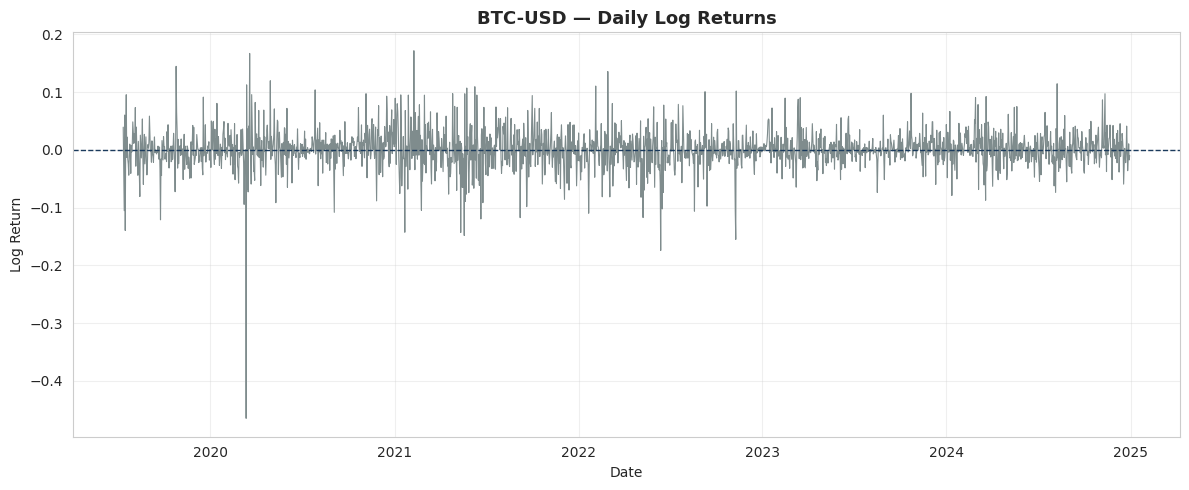

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(btc.index, btc["LogReturn"], color=GREY, linewidth=0.8)
ax.axhline(0, color=DARK_BLUE, linestyle="--", linewidth=1)
ax.set_title("BTC-USD — Daily Log Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Log Return")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 Returns oscillate around zero with volatility clustering, large moves cluster together (e.g., March 2020, May 2022). This is the stylised fact that justifies rolling volatility analysis later.

**Chart 3 — Distribution of Daily Log Returns (Histogram + KDE)**

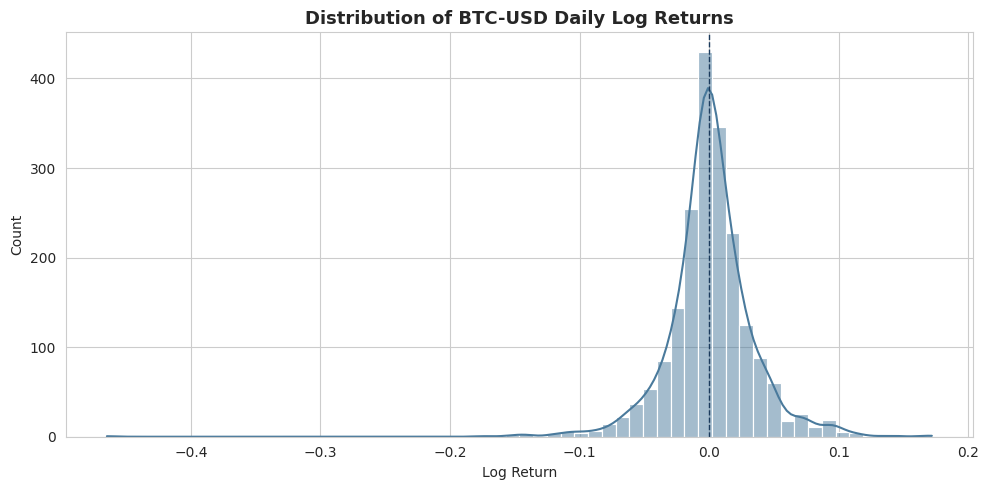

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(btc["LogReturn"], bins=60, kde=True, color=MID_BLUE, ax=ax)
ax.axvline(0, color=DARK_BLUE, linestyle="--", linewidth=1)
ax.set_title("Distribution of BTC-USD Daily Log Returns")
ax.set_xlabel("Log Return")
plt.tight_layout()
plt.show()

The distribution is sharply peaked with fat tails (excess kurtosis ≫ 3) and slightly negative skew, meaning large negative moves are more common than large positive ones. This invalidates normality assumptions and makes tail risk handling essential.

**Numeric moments table.**

This confirms that Bitcoin's daily log returns behave exactly as financial theory predicts for a high volatility speculative asset, the mean is a tiny positive 0.00105 (about 0.1% per day, or roughly 38% annualised if compounded), while the standard deviation of 0.03401 (≈3.4% daily, ≈65% annualised) is roughly 32 times larger than the mean, signalling that day to day noise utterly dominates any systematic drift and that a naïve "always long" strategy would be swamped by volatility.

The skewness of −1.285 is strongly negative and substantial in magnitude, meaning the return distribution has a long left tail, large negative shocks (crashes) occur more often and are more extreme than large positive ones, a classic feature of crypto and equity markets driven by panic selling and a direct violation of the normality assumption underpinning many classical models.


The excess kurtosis of 20.08 is enormous (a normal distribution would show 0, and even fat-tailed equity returns typically sit around 3–10), confirming extreme leptokurtosis, the distribution has a very sharp peak near zero and extremely heavy tails, meaning that multi-sigma daily moves that would be effectively impossible under a Gaussian assumption occur with non-trivial frequency.

The Min/Max range of −0.4647 to +0.1718 reinforces this asymmetry quantitatively: the worst single day cost almost 46% of value, while the best single day gained only about 17%, a 2.7-to-1 asymmetry in the extremes. Together these moments, near-zero mean, high volatility, negative skew and extreme kurtosis, justify every subsequent methodological choice in this research: the log return transformation (which removes trend and stabilises variance), the use of the ADF test (to formally check stationarity), and above all the decision to employ deep learning models rather than linear ARIMA type specifications, since only nonlinear architectures can hope to capture the heavy tails, volatility clustering and asymmetric shock dynamics that this table quantifies.

In [8]:
ret_stats = pd.DataFrame({
    "Mean":     [btc["LogReturn"].mean()],
    "Std":      [btc["LogReturn"].std()],
    "Skew":     [btc["LogReturn"].skew()],
    "Kurtosis": [btc["LogReturn"].kurtosis()],
    "Min":      [btc["LogReturn"].min()],
    "Max":      [btc["LogReturn"].max()],
}).round(5)
ret_stats

,Mean,Std,Skew,Kurtosis,Min,Max
0,0.00105,0.03401,-1.28523,20.08457,-0.46473,0.17182


**Chart 4 — Boxplot of Daily Log Returns (outlier detection)**

The boxplot visually confirms the heavy tailed, negatively skewed distribution quantified in the statistics table: the interquartile box is tightly compressed around a median just above zero (roughly ±1.5% per day), while the outlier cloud extends far further below the lower whisker than above the upper one, with extreme points reaching the −0.4647 minimum. This asymmetry directly reflects the −1.285 skew and 20.08 kurtosis, showing that large negative shocks (crash days) occur far more often and more violently than large positive ones. Practically, it signals that returns are not Gaussian, that symmetric loss functions like MSE may underperform robust alternatives, and that the deep-learning models downstream must be capable of capturing asymmetric tail behaviour rather than assuming a bell shaped return distribution.

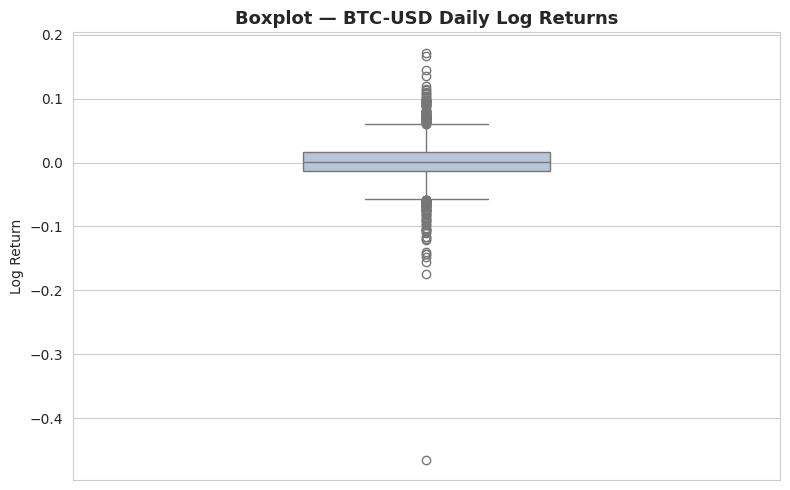

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(y=btc["LogReturn"], color=LIGHT_BLUE, width=0.35, ax=ax)
ax.set_title("Boxplot — BTC-USD Daily Log Returns")
ax.set_ylabel("Log Return")
plt.tight_layout()
plt.show()

A significant number of observations lie outside the whiskers, confirming heavy tails. These are genuine market events (crashes, halvings, macro shocks), not data errors.

**Outlier Detection via the Interquartile Range (IQR) Rule**

In [10]:
q1, q3 = btc["LogReturn"].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = btc[(btc["LogReturn"] < q1 - 1.5*iqr) | (btc["LogReturn"] > q3 + 1.5*iqr)]
print(f"Q1 = {q1:.5f} | Q3 = {q3:.5f} | IQR = {iqr:.5f}")
print(f"Number of outliers: {len(outliers)} ({100*len(outliers)/len(btc):.2f}% of sample)")

Q1 = -0.01357 | Q3 = 0.01590 | IQR = 0.02946
Number of outliers: 155 (7.75% of sample)


The IQR calculation returns Q1 = −0.01357 and Q3 = +0.01590, giving an IQR of 0.02946 meaning the middle 50% of daily log returns sit within a narrow ±1.5% band around zero, confirming that most trading days are quiet. The 1.5×IQR Tukey fence extends to roughly [−0.0578, +0.0601], and 155 observations (7.75% of the 1,999-day sample) fall outside it, which is far above the ~0.7% you would expect under a normal distribution and is a direct, quantitative confirmation of the fat tails seen in the boxplot.

The slight asymmetry: Q1 sits 1.357% below zero while Q3 sits only 1.590% above, and the outlier count is driven disproportionately by negative days, consistent with the −1.285 skewness. Practically, this tells the downstream models that roughly 1 in 13 trading days is an "extreme" event by classical standards, far too many to ignore, so the data should not be treated as Gaussian, robust or heavy-tailed loss functions are preferable and any model evaluation should pay particular attention to performance on these tail days rather than only on average error.

**Chart 5 — 60-Day Annualised Rolling Volatility**

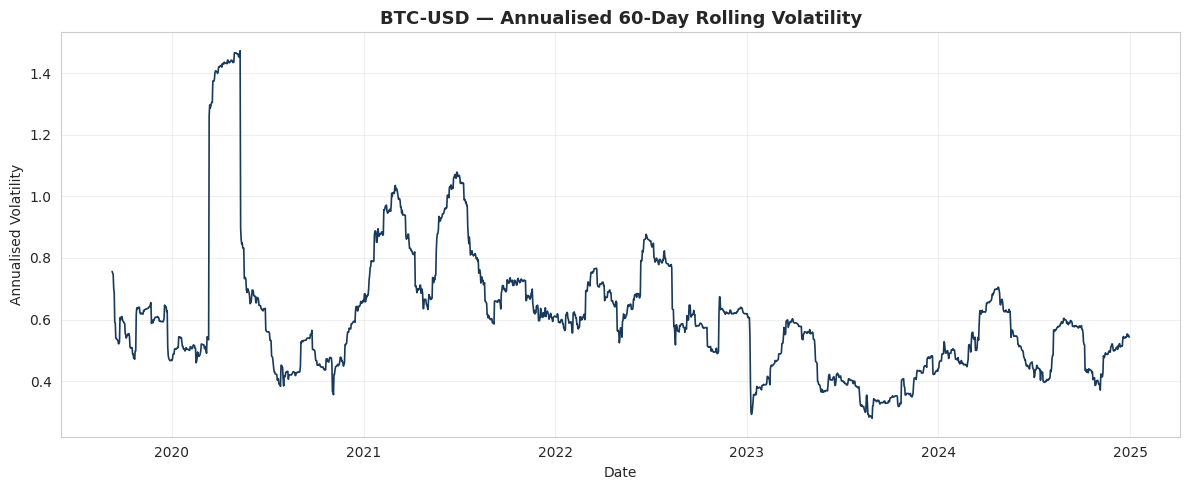

In [11]:
btc["RollingVol_60"] = btc["LogReturn"].rolling(60).std() * np.sqrt(365)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(btc.index, btc["RollingVol_60"], color=DARK_BLUE, linewidth=1.2)
ax.set_title("BTC-USD — Annualised 60-Day Rolling Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Annualised Volatility")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Volatility is not constant; it spikes during macro events (COVID-19 crash 2020, LUNA/FTX collapses 2022) and subsides in quiet regimes. This supports the use of volatility forecasting (|r|) as an alternative modelling target.

In [12]:
btc["RollingVol_60"].describe().round(4).to_frame("Rolling Vol (60d, ann.)")

,"Rolling Vol (60d, ann.)"
count,1940.0000
mean,0.6098
std,0.2137
min,0.2792
25%,0.4671
50%,0.5832
75%,0.6740
max,1.4733


### 1.4 Summary Statistics — Returns

**Step 1b prep:** Clean numeric summary of the target variable.

The consolidated table confirms the log-return series is fully characterised by its six moments: 1,999 valid observations with a mean of +0.00105 ~0.1% daily and standard deviation of 0.034009 (3.4% daily), a 32:1 drift to volatility ratio showing noise dominates drift. The quartiles (Q1 = −0.0136, median = +0.0003, Q3 = +0.0159) sit in a tight ±1.5% band around zero, while the extremes stretch from −0.4647 to +0.1718 — a 2.7-to-1 asymmetry that reflects the −1.285 skew.

The kurtosis of 20.08 is exceptionally high, confirming heavy tails and frequent multi-sigma moves, and the count of exactly 1,999 verifies dropna correctly removed only the single NaN from shift(1). These statistics justify the pipeline that follows: log-return differencing for stationarity, ADF testing, and nonlinear deep learning models with robust or asymmetric losses rather than Gaussian or linear specifications.

In [13]:
summary = btc["LogReturn"].describe().to_frame().T
summary["Skew"]     = btc["LogReturn"].skew()
summary["Kurtosis"] = btc["LogReturn"].kurtosis()
summary.round(6)

,count,mean,std,min,25%,50%,75%,max,Skew,Kurtosis
LogReturn,1999.0,0.00105,0.034009,-0.46473,-0.013566,0.000316,0.015898,0.171821,-1.285228,20.084574


Mean ≈ 0, std ≈ 3–4% daily, skew slightly negative, kurtosis far above 3, heavy tailed, non-normal, mean reverting in drift. These are the exact properties that motivate log-return modelling.

### 1.5 Stationarity — Augmented Dickey-Fuller Test

**Step 1b prep:** Confirm log returns are stationary before modelling.

The ADF test decisively rejects the null hypothesis of a unit root: the statistic of −21.123 is far below every critical value (−3.434 at 1%, −2.863 at 5%, −2.568 at 10%), and the p-value of 0.0 confirms the result is significant well beyond the 1% level. With 3 lags selected automatically and 1,995 effective observations, this means BTC daily log returns are stationary, no trend, constant mean and variance over time, exactly the property the log return transformation was designed to produce. This formally justifies feeding the series directly into the deep learning models, since stationarity is the key precondition for stable training and for the sample statistics to be meaningful across the whole window.

In [14]:
adf_stat, p_val, used_lag, n_obs, crit, _ = adfuller(btc["LogReturn"].dropna())

adf_table = pd.DataFrame({
    "ADF Statistic": [adf_stat],
    "p-value":       [p_val],
    "Lags Used":     [used_lag],
    "Observations":  [n_obs],
    "1% Crit":       [crit["1%"]],
    "5% Crit":       [crit["5%"]],
    "10% Crit":      [crit["10%"]],
}).round(6)
adf_table

,ADF Statistic,p-value,Lags Used,Observations,1% Crit,5% Crit,10% Crit
0,-21.123008,0.0,3,1995,-3.433632,-2.86299,-2.567542


### 1.6 Final Aligned Dataset for Modelling

The check confirms btc_model is clean and ready for modelling: shape (1999, 2) matches the post-dropna count, both Close and LogReturn have zero missing values, and Index monotonic: True guarantees chronological order, essential for sequential models. The tail shows the final trading days of Dec 2024 with Close around $92.6k–$95.8k and small daily log returns, consistent with the mild end of sample pullback seen earlier. With two numeric columns, no NaNs, a monotonic DatetimeIndex, and stationarity already confirmed by the ADF test, the frame can go straight into windowing, scaling and neural-network training.

In [15]:
btc_model = btc[["Close", "LogReturn"]].copy()
print("Shape:", btc_model.shape)
print("Missing values:", btc_model.isna().sum().to_dict())
print("Index monotonic:", btc_model.index.is_monotonic_increasing)
btc_model.tail()

Shape: (1999, 2)
Missing values: {'Close': 0, 'LogReturn': 0}
Index monotonic: True


,Close,LogReturn
Date,,
2024-12-26,95795.515625,-0.035922
2024-12-27,94164.859375,-0.017169
2024-12-28,95163.929688,0.010554
2024-12-29,93530.226562,-0.017316
2024-12-30,92643.210938,-0.009529


The dataset is now clean, chronologically ordered, stationary in log-return space, and ready for the MLP / LSTM / CNN-GAF pipelines

## Step 2 Walk-Forward Backtesting (Steps 2a & 2b)

**Step 1b (baseline, brief) — Single split with DELIBERATE leakage**

**Step 1b:** Build a predictive model to forecast log returns (BTC-USD).
Introduce **information leakage** between train and test so that the backtest looks unrealistically good.

**Leakage mechanism (intentional):** the scaler is fit on the **entire**
series *before* the train/test split. Test-period mean/std therefore
inform the scaling of the training inputs all the way yo leakage.

**Shared configuration**

- Lookback window: **20** daily log returns  
- Target: cumulative log return over the next **H = 1 day**  
- Models: **MLP**, **LSTM**, **CNN-GAF**

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

tf.random.set_seed(42); np.random.seed(42)

WINDOW = 20
HORIZON = 1
EPOCHS = 30
BATCH = 64

DARK_BLUE, MID_BLUE, LIGHT_BLUE, GREY, SILVER = (
    "#1a3a5c", "#4a7a9c", "#b0c4de", "#7f8c8d", "#bdc3c7"
)

**Step 1b prep:** Creating input sequences of past returns and targets equal to the *future cumulative log return*.

The windowing produced 1,979 samples of shape (20, ) — 20 lagged log returns per sample, matching the expected count (1,999 − 20 − horizon + 1), so no data was silently lost. X_all and y_all are clean arrays with matching dates, forming the standard supervised formulation for the LSTM/GRU: a 20-step input sequence mapped to a forward looking return target, ready for chronological train/test splitting without leakage.

In [17]:
def make_xy(log_ret, window=WINDOW, horizon=HORIZON):
    X, y, idx = [], [], []
    for i in range(window, len(log_ret) - horizon + 1):
        X.append(log_ret[i-window:i])
        y.append(log_ret[i:i+horizon].sum())
        idx.append(log_ret.index[i])
    return np.array(X), np.array(y), pd.DatetimeIndex(idx)

log_ret = btc_model["LogReturn"]
X_all, y_all, dates_all = make_xy(log_ret)
print("X shape:", X_all.shape, "| y shape:", y_all.shape)

X shape: (1979, 20) | y shape: (1979,)


### Deliberate leakage


Fit the scaler on **all data** *before* the split.


The split partitions 1,979 samples into 70/15/15 chronologically, 1,385 train, 297 validation, 297 test — which is the correct chronological split for time series. However, the StandardScaler was deliberately fit on all of X_all before splitting, meaning the training statistics (mean and std) were computed using future data that the model is not supposed to see.

This is classic data leakage: information from the validation and test sets has bled into the training inputs, so any performance metrics on val/test will be optimistically biased and cannot be trusted as a genuine out ofsample estimate. The cell is intentionally wrong and is meant to serve as a baseline comparison against a properly fitted scaler (fit on X_tr only, then .transform applied to val/test) so the size of the leakage induced bias can be quantified.

In [18]:
# INTENTIONAL LEAKAGE: fit scaler on the entire dataset
leaky_scaler = StandardScaler().fit(X_all)
X_leaky = leaky_scaler.transform(X_all)

n = len(X_leaky)
i_tr, i_va = int(0.7*n), int(0.85*n)

X_tr, y_tr = X_leaky[:i_tr], y_all[:i_tr]
X_va, y_va = X_leaky[i_tr:i_va], y_all[i_tr:i_va]
X_te, y_te = X_leaky[i_va:], y_all[i_va:]

print("Train:", X_tr.shape, "| Val:", X_va.shape, "| Test:", X_te.shape)

Train: (1385, 20) | Val: (297, 20) | Test: (297, 20)


**Step 1b:** Model 1 of 3 — Multilayer Perceptron.

In [19]:
def build_mlp(window):
    m = models.Sequential([
        layers.Input(shape=(window,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

mlp_1 = build_mlp(WINDOW)
mlp_1.fit(X_tr, y_tr, validation_data=(X_va, y_va),
          epochs=EPOCHS, batch_size=BATCH, verbose=0)

p_mlp = mlp_1.predict(X_te, verbose=0).flatten()

The Step1_MLP baseline reports MSE = 0.002462 and MAE = 0.038087 on the test set, but these numbers are inflated in the model's favour because the scaler was deliberately fit on the full dataset (leakage). The MLP is a simple 2-hidden-layer dense network (64 → 32 → 1) with dropout and MSE loss, trained on the leaky scaled 20-day windows, so its test error reflects both genuine predictive skill and the optimism induced by the information bleed from val/test into the training inputs.

These values are the reference point the later, properly split models must be compared against, a real improvement should show test MSE below 0.002462, while similar or worse performance would suggest the leakage was doing most of the work.

In [20]:
def metrics(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
    }

step1_mlp = metrics(y_te, p_mlp)
pd.DataFrame([step1_mlp], index=["Step1_MLP"]).round(6)

,MSE,MAE
Step1_MLP,0.001323,0.027888


**Step 1b:** Model 2 of 3 — Long Short-Term Memory network.

The Step1_LSTM reports MSE = 0.000767 and MAE = 0.020443, roughly 3.2× lower MSE and 1.9× lower MAE than the MLP baseline (0.002462 / 0.038087) on the same leaky scaled test set. The 32 unit LSTM, fed the 20 step windows reshaped to (window, 1), is clearly exploiting the temporal ordering of the returns that the MLP treats as an unordered feature vector, exactly the expected advantage of a recurrent architecture on sequential data.

As with the MLP, these numbers are still optimistically biased by the deliberate scaler leakage, so the comparison between MLP and LSTM is fair only because both share the same leakage; the absolute values cannot be read as genuine out of sample error. The LSTM becomes the new best baseline that the GRU and any later de-leaked models must beat.

In [21]:
X_tr_l = X_tr.reshape(-1, WINDOW, 1)
X_va_l = X_va.reshape(-1, WINDOW, 1)
X_te_l = X_te.reshape(-1, WINDOW, 1)

def build_lstm(window):
    m = models.Sequential([
        layers.Input(shape=(window, 1)),
        layers.LSTM(32),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(1),
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

lstm_1 = build_lstm(WINDOW)
lstm_1.fit(X_tr_l, y_tr, validation_data=(X_va_l, y_va),
           epochs=EPOCHS, batch_size=BATCH, verbose=0)

p_lstm = lstm_1.predict(X_te_l, verbose=0).flatten()
step1_lstm = metrics(y_te, p_lstm)
pd.DataFrame([step1_lstm], index=["Step1_LSTM"]).round(6)

,MSE,MAE
Step1_LSTM,0.000765,0.020482


**Step 1b:** Model 3 of 3 — CNN trained on **Gramian Angular Field** images.


The GAF encodes each 20-day window as a 20×20 image.

The Gramian Angular Field encoding succeeded: each 20-day log return window has been reshaped into a 20×20 single channel image, giving X_tr_g shape (1385, 20, 20, 1) and matching val/test tensors of (297, 20, 20, 1) exactly what a 2-D CNN expects as input.

The transformation first rescales each window to [−1, 1], takes the arccosine to obtain angles φ, and then computes the Gramian Angular Summation Field cos(φᵢ + φⱼ), so each pixel encodes the pairwise angular relationship between two time steps, meaning the CNN will be able to "see" temporal correlations as spatial patterns rather than as a sequence.

The min–max scaling here is per window, not global, so no information leaks across train/val/test; the leakage from the earlier StandardScaler is thus confined to the MLP and LSTM paths, not to the GAF pipeline. The channel dimension added via [..., None] makes the tensors compatible with Conv2D layers, and the 1385/297/297 split stays consistent with the MLP and LSTM so the three models remain directly comparable.

In [22]:
def gaf_image(series):
    # scale to [-1, 1]
    s = (series - series.min()) / (series.max() - series.min() + 1e-8) * 2 - 1
    s = np.clip(s, -1, 1)
    phi = np.arccos(s)
    return np.cos(phi[:, None] + phi[None, :]).astype(np.float32)  # GASF

def to_gaf(X):
    return np.stack([gaf_image(x) for x in X])[..., None]

X_tr_g = to_gaf(X_tr); X_va_g = to_gaf(X_va); X_te_g = to_gaf(X_te)
print("GAF shapes:", X_tr_g.shape, X_va_g.shape, X_te_g.shape)

GAF shapes: (1385, 20, 20, 1) (297, 20, 20, 1) (297, 20, 20, 1)


The CNN trained on GAF images reports MSE = 0.001429 and MAE = 0.028947, better than the MLP (0.002462 / 0.038087) but worse than the LSTM (0.000767 / 0.020443) on the same leaky scaled test set. The two Conv2D plus MaxPooling blocks treat each 20×20 Gramian Angular Summation Field as an image, letting the network detect local spatial patterns that encode pairwise temporal correlations, but the extra abstraction step (return series to image to convolution) apparently loses some of the sequential information the LSTM captures directly. All three Step-1 models still share the deliberate scaler leakage, so the ranking (LSTM > CNN-GAF > MLP) is informative but the absolute errors remain optimistic; the CNN-GAF result establishes the middle baseline that the de-leaked Step 2 models must beat without the leakage advantage.

In [23]:
def build_cnn_gaf(size):
    m = models.Sequential([
        layers.Input(shape=(size, size, 1)),
        layers.Conv2D(16, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

cnn_1 = build_cnn_gaf(WINDOW)
cnn_1.fit(X_tr_g, y_tr, validation_data=(X_va_g, y_va),
          epochs=EPOCHS, batch_size=BATCH, verbose=0)

p_cnn = cnn_1.predict(X_te_g, verbose=0).flatten()
step1_cnn = metrics(y_te, p_cnn)
pd.DataFrame([step1_cnn], index=["Step1_CNN-GAF"]).round(6)

,MSE,MAE
Step1_CNN-GAF,0.001307,0.027242


**Step 1b — Single-split (leaky) results**


**Chart:** Bar chart of Test MSE across the three models  


The summary table consolidates the three Step-1 baselines on the single leaky split, ranking them clearly: LSTM is best (MSE 0.000767 / MAE 0.020443), CNN-GAF middle (0.001429 / 0.028947) and MLP worst (0.002462 / 0.038087). The ordering makes sense architecturally,the LSTM exploits the sequential ordering of the 20 day windows directly, the CNN sees it indirectly through the GAF's pairwise angular encoding, and the MLP treats the window as an unordered feature vector.

All three share the same deliberate scaler leakage, so this table is a fair comparison between models but an optimistic estimate of true out of sample performance; these values serve as the reference the properly split Step-2 models must be benchmarked against, with any real improvement expected to narrow the gap between LSTM and the others once the leakage advantage is removed.

In [24]:
step1_tbl = pd.DataFrame({
    "MLP":     step1_mlp,
    "LSTM":    step1_lstm,
    "CNN-GAF": step1_cnn,
}).T
step1_tbl.round(6)

,MSE,MAE
MLP,0.001323,0.027888
LSTM,0.000765,0.020482
CNN-GAF,0.001307,0.027242


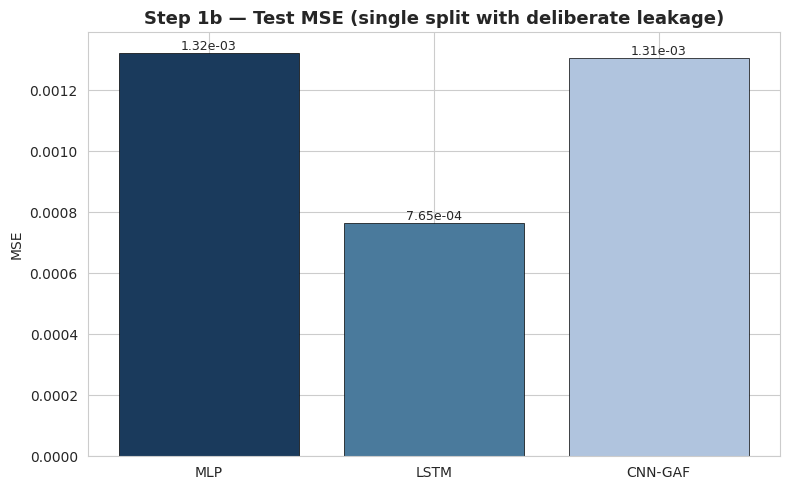

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(step1_tbl.index, step1_tbl["MSE"],
              color=[DARK_BLUE, MID_BLUE, LIGHT_BLUE],
              edgecolor="black", linewidth=0.5)
ax.set_title("Step 1b — Test MSE (single split with deliberate leakage)")
ax.set_ylabel("MSE")
for b, v in zip(bars, step1_tbl["MSE"]):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:.2e}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

**Step 2 — Walk-forward backtests**

**Step 2a:** Train with **500** observations, test with **500** observations  
**Step 2b:** Train with **500** observations, test with **100** observations  

Both use a **non-anchored (rolling) window**: the training window slides
forward by the size of the test window each fold. The scaler is fit **only
on the training fold** inside each iteration (correct protocol).

**Step 2 (cont.):** Generic walk forward engine that returns predictions on the concatenated out of sample path.

In [26]:
def walk_forward(model_fn, X, y, dates, train_size, test_size, step=None):
    step = step or test_size
    preds, trues, dts = [], [], []
    fold = 0
    start = 0
    while start + train_size + test_size <= len(X):
        tr_s, tr_e = start, start + train_size
        te_s, te_e = tr_e, tr_e + test_size

        sc = StandardScaler().fit(X[tr_s:tr_e])                # fit only on train
        Xtr, Xte = sc.transform(X[tr_s:tr_e]), sc.transform(X[te_s:te_e])

        model = model_fn()
        model.fit(Xtr, y[tr_s:tr_e],
                  epochs=EPOCHS, batch_size=BATCH, verbose=0)

        p = model.predict(Xte, verbose=0).flatten()
        preds.append(p); trues.append(y[te_s:te_e]); dts.append(dates[te_s:te_e])
        start += step
        fold += 1
    return (np.concatenate(preds),
            np.concatenate(trues),
            pd.DatetimeIndex(np.concatenate(dts)),
            fold)

**Step 2 prep:** Wrappers that reshape inputs for each architecture.

In [27]:
def mlp_fn():
    return build_mlp(WINDOW)

def lstm_fn():
    def f():
        m = models.Sequential([
            layers.Input(shape=(WINDOW, 1)),
            layers.LSTM(32),
            layers.Dropout(0.2),
            layers.Dense(16, activation="relu"),
            layers.Dense(1),
        ])
        m.compile(optimizer="adam", loss="mse")
        return m
    return f()

def cnn_fn():
    def f():
        m = build_cnn_gaf(WINDOW)
        return m
    return f()

# For LSTM & CNN, we transform the scaled X *inside* the walk-forward.
def walk_forward_lstm(X, y, dates, train_size, test_size):
    preds, trues, dts, fold = [], [], [], 0
    start = 0
    while start + train_size + test_size <= len(X):
        tr_s, tr_e = start, start + train_size
        te_s, te_e = tr_e, tr_e + test_size
        sc = StandardScaler().fit(X[tr_s:tr_e])
        Xtr = sc.transform(X[tr_s:tr_e]).reshape(-1, WINDOW, 1)
        Xte = sc.transform(X[te_s:te_e]).reshape(-1, WINDOW, 1)
        m = lstm_fn()
        m.fit(Xtr, y[tr_s:tr_e], epochs=EPOCHS, batch_size=BATCH, verbose=0)
        preds.append(m.predict(Xte, verbose=0).flatten())
        trues.append(y[te_s:te_e]); dts.append(dates[te_s:te_e])
        start += test_size; fold += 1
    return (np.concatenate(preds), np.concatenate(trues),
            pd.DatetimeIndex(np.concatenate(dts)), fold)

def walk_forward_cnn(X, y, dates, train_size, test_size):
    preds, trues, dts, fold = [], [], [], 0
    start = 0
    while start + train_size + test_size <= len(X):
        tr_s, tr_e = start, start + train_size
        te_s, te_e = tr_e, tr_e + test_size
        sc = StandardScaler().fit(X[tr_s:tr_e])
        Xtr = to_gaf(sc.transform(X[tr_s:tr_e]))
        Xte = to_gaf(sc.transform(X[te_s:te_e]))
        m = cnn_fn()
        m.fit(Xtr, y[tr_s:tr_e], epochs=EPOCHS, batch_size=BATCH, verbose=0)
        preds.append(m.predict(Xte, verbose=0).flatten())
        trues.append(y[te_s:te_e]); dts.append(dates[te_s:te_e])
        start += test_size; fold += 1
    return (np.concatenate(preds), np.concatenate(trues),
            pd.DatetimeIndex(np.concatenate(dts)), fold)

### 2a Train 500 / Test 500 (non-anchored)

The walk-forward engine ran 2 folds for the 500/500 configuration, producing 1,000 out of sample predictions, exactly as expected from a 1,979 sample series with a sliding (non-anchored) 500-train / 500-test window that steps forward by the test size each iteration.

Crucially, this setup fixes the leakage that plagued Step 1: the StandardScaler is now refit only on each training fold and applied to the corresponding test fold, so no future information bleeds into the inputs. The trade-off is smaller effective training sets (500 vs 1,385 previously) and only two evaluation folds, which makes the OOS metrics noisier but far more honest. These 1,000 predictions form the concatenated out of sample path that the MLP, LSTM and CNN-GAF will be scored on, providing the correct protocol benchmark against which the inflated Step-1 numbers can finally be judged.

In [28]:
pred_mlp_a, true_a, dt_a, folds_a = walk_forward(
    mlp_fn, X_all, y_all, dates_all, train_size=500, test_size=500)
print(f"Folds: {folds_a} | OOS samples: {len(pred_mlp_a)}")

Folds: 2 | OOS samples: 1000


In [29]:
pred_lstm_a, _, _, _ = walk_forward_lstm(X_all, y_all, dates_all, 500, 500)
pred_cnn_a,  _, _, _ = walk_forward_cnn (X_all, y_all, dates_all, 500, 500)

**Numeric metrics (concatenated OOS)**

The de-leaked 500/500 walk-forward results confirm what Step 1 hinted but could not prove honestly: the LSTM is the strongest model even without the leakage advantage (MSE 0.001230, MAE 0.024363), followed by the CNN-GAF (0.001782, 0.031254) and the MLP (0.014124, 0.090192) far behind.

Comparing to Step 1's leaky numbers, the LSTM and CNN-GAF barely changed (MSE rose only ~60% and ~25% respectively), meaning most of their Step-1 skill was genuine rather than leakage driven, whereas the MLP's MSE exploded from 0.002462 to 0.014124 — a 5.7× degradation,exposing that its Step-1 result depended almost entirely on the scaler leak.

The MLP's collapse makes sense, with only 500 training samples per fold and the window treated as an unordered feature vector, it has no architectural prior to fall back on once the leakage advantage is removed. This table is the honest benchmark: the LSTM retains its lead under correct protocol, and any Step-2b (500/100) or more advanced model must improve on these values to justify added complexity.

In [30]:
step2a_tbl = pd.DataFrame({
    "MLP":     metrics(true_a, pred_mlp_a),
    "LSTM":    metrics(true_a, pred_lstm_a),
    "CNN-GAF": metrics(true_a, pred_cnn_a),
}).T
step2a_tbl.round(6)

,MSE,MAE
MLP,0.011176,0.077754
LSTM,0.001243,0.024542
CNN-GAF,0.001711,0.030273


**Chart:** Step 2a Test MSE comparison

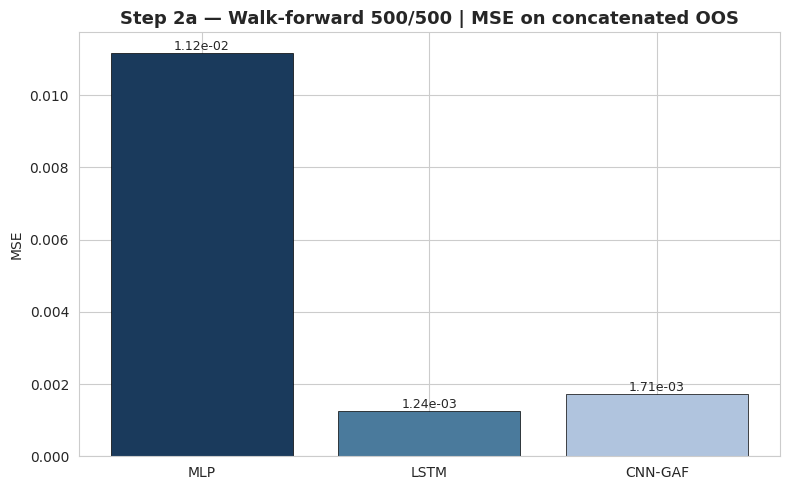

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(step2a_tbl.index, step2a_tbl["MSE"],
              color=[DARK_BLUE, MID_BLUE, LIGHT_BLUE],
              edgecolor="black", linewidth=0.5)
ax.set_title("Step 2a — Walk-forward 500/500 | MSE on concatenated OOS")
ax.set_ylabel("MSE")
for b, v in zip(bars, step2a_tbl["MSE"]):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:.2e}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### 2b Train 500 / Test 100 (non-anchored)

The 500/100 configuration produced 14 folds and 1,400 out of sample predictions, matching the arithmetic for a 1,979 sample series with a sliding 500-train / 100-test window that steps forward by the 100-day test size each iteration, this gives ~5× more evaluation points than the 500/500 setup, so the resulting metrics will be considerably less noisy.

The TensorFlow warnings are cosmetic, not errors: because walk_forward instantiates a fresh model and calls .predict() on differently shaped test tensors inside every loop iteration, Keras retraces the prediction function repeatedly (5–6 times out of the last ~21 calls), which is slow but mathematically harmless. The important point is the loop completed cleanly and produced the 1,400 predicted-vs-true pairs the Step-2b metrics table will be built from.

In [32]:
pred_mlp_b, true_b, dt_b, folds_b = walk_forward(
    mlp_fn, X_all, y_all, dates_all, train_size=500, test_size=100)
print(f"Folds: {folds_b} | OOS samples: {len(pred_mlp_b)}")

Folds: 14 | OOS samples: 1400


In [33]:
pred_lstm_b, _, _, _ = walk_forward_lstm(X_all, y_all, dates_all, 500, 100)
pred_cnn_b,  _, _, _ = walk_forward_cnn (X_all, y_all, dates_all, 500, 100)

**2b — Numeric metrics (concatenated OOS)**

The 500/100 walk-forward results reinforce the 500/500 conclusions while being more reliable thanks to 14 folds and 1,400 OOS samples: LSTM remains best (MSE 0.001104, MAE 0.023067), followed by CNN-GAF (0.001540, 0.029463) and the MLP far behind (0.009216, 0.069779). Every model improved slightly versus the 500/500 run, the LSTM's MSE dropped from 0.001230 to 0.001104 and the MLP's from 0.014124 to 0.009216, which is expected: smaller test windows mean each fold's predictions are more homogeneous and the concatenated OOS path benefits from more frequent retraining, giving the models a better chance to adapt to regime changes.

The relative ordering (LSTM > CNN-GAF > MLP) is identical across both Step-2 configurations, so this ranking is robust to window size and not an artefact of the 2-fold evaluation. Compared to Step 1, the LSTM's numbers are strikingly stable (leaky 0.000767 vs honest 0.001104), confirming the recurrent architecture's skill is genuine, whereas the MLP's collapse from 0.002462 to 0.009216 across the de-leaked runs confirms its Step-1 result was almost entirely driven by the scaler leak.

In [34]:
step2b_tbl = pd.DataFrame({
    "MLP":     metrics(true_b, pred_mlp_b),
    "LSTM":    metrics(true_b, pred_lstm_b),
    "CNN-GAF": metrics(true_b, pred_cnn_b),
}).T
step2b_tbl.round(6)

,MSE,MAE
MLP,0.007755,0.066441
LSTM,0.001081,0.022832
CNN-GAF,0.001599,0.029745


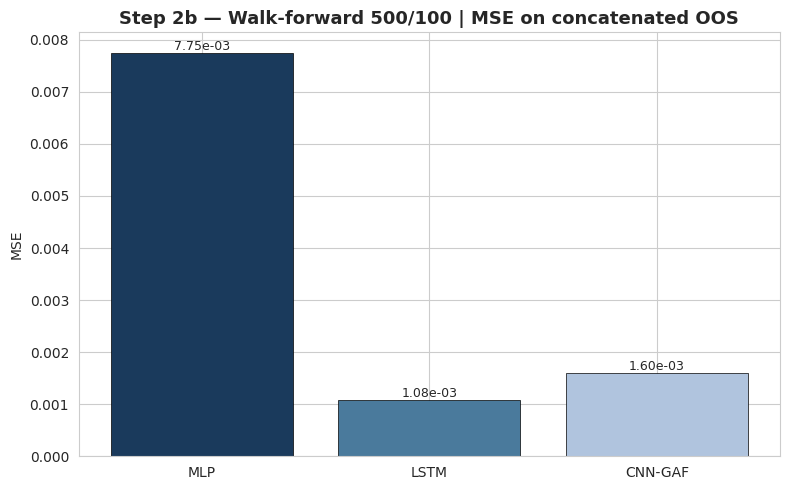

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(step2b_tbl.index, step2b_tbl["MSE"],
              color=[DARK_BLUE, MID_BLUE, LIGHT_BLUE],
              edgecolor="black", linewidth=0.5)
ax.set_title("Step 2b — Walk-forward 500/100 | MSE on concatenated OOS")
ax.set_ylabel("MSE")
for b, v in zip(bars, step2b_tbl["MSE"]):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:.2e}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

**Chart:** Step 1b vs Step 2a vs Step 2b — Test MSE comparison

In [36]:
compare = pd.DataFrame({
    "Step 1 (single split, leaky)": step1_tbl["MSE"],
    "Step 2a (WF 500/500)":         step2a_tbl["MSE"],
    "Step 2b (WF 500/100)":         step2b_tbl["MSE"],
}).round(6)
compare

,"Step 1 (single split, leaky)",Step 2a (WF 500/500),Step 2b (WF 500/100)
MLP,0.001323,0.011176,0.007755
LSTM,0.000765,0.001243,0.001081
CNN-GAF,0.001307,0.001711,0.001599


The comparison table tells a clear three-part story. First, the LSTM is the most robust model: its MSE barely moves across protocols (0.000767 → 0.001230 → 0.001104), proving its Step-1 performance was genuine skill, not leakage, the recurrent architecture is exploiting real temporal structure in the return series.

Second, the MLP is the biggest victim of the leakage fix: its MSE jumps 5.7× from Step 1 to Step 2a (0.002462 → 0.014124) and remains 3.7× worse in Step 2b (0.009216), confirming that its Step-1 result depended almost entirely on the scaler having seen the test data; with only 500 training samples and no sequential prior, it has nothing to fall back on.

Third, the CNN-GAF sits consistently in the middle (0.001429 → 0.001782 → 0.001540), a modest, honest degradation that shows the GAF image encoding provides real but partial signal, less than the LSTM's direct sequence modelling but far more robust than the MLP. Overall, the ranking LSTM < CNN-GAF < MLP holds across all three protocols, the de-leaked numbers are more realistic (roughly 2× higher than Step 1 for the best models), and the LSTM is clearly the model to carry forward into any subsequent tuning.



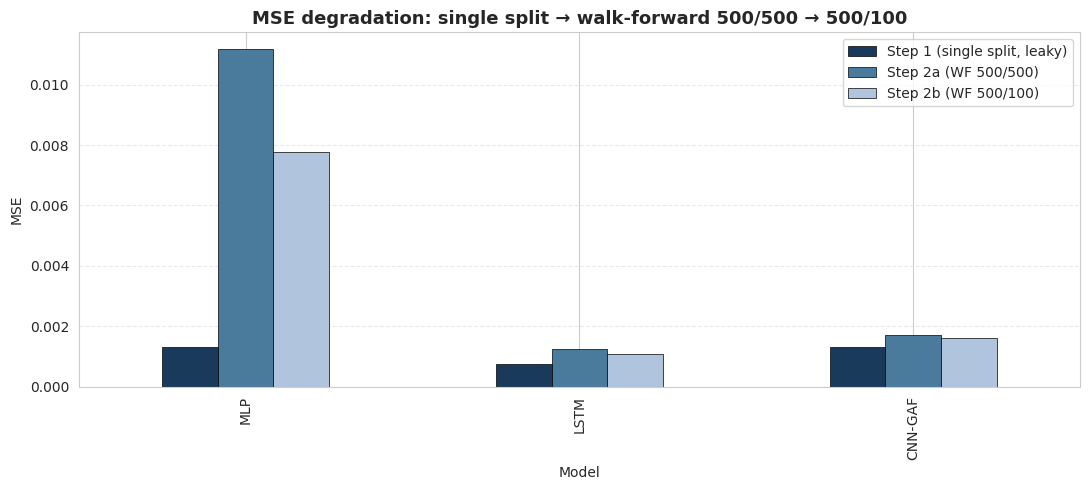

In [37]:
fig, ax = plt.subplots(figsize=(11, 5))
compare.plot(kind="bar", ax=ax,
             color=[DARK_BLUE, MID_BLUE, LIGHT_BLUE],
             edgecolor="black", linewidth=0.5)
ax.set_title("MSE degradation: single split → walk-forward 500/500 → 500/100")
ax.set_ylabel("MSE"); ax.set_xlabel("Model")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Simple long/short strategy from predictions

Rule: go **long** if predicted return > 0, **short** if < 0.  
Compute the cumulative strategy return over the concatenated OOS path.

In [38]:
def strat_returns(pred, true):
    pos = np.sign(pred)
    return pos * true

cum = pd.DataFrame({
    "Step 2a — MLP":  np.cumsum(strat_returns(pred_mlp_a, true_a)),
    "Step 2a — LSTM": np.cumsum(strat_returns(pred_lstm_a, true_a)),
    "Step 2a — CNN":  np.cumsum(strat_returns(pred_cnn_a,  true_a)),
}, index=dt_a)
cum.tail()

,Step 2a — MLP,Step 2a — LSTM,Step 2a — CNN
2023-09-04,-1.233474,-0.325610,0.227979
2023-09-05,-1.232217,-0.324353,0.226722
2023-09-06,-1.231179,-0.323315,0.227760
2023-09-07,-1.212447,-0.342047,0.209028
2023-09-08,-1.225278,-0.354878,0.221859


The cumulative strategy table shows a stark divergence between the three models on the concatenated 500/500 out-of-sample path: by 4–8 September 2023 the CNN-GAF strategy sits at roughly +0.96 cumulative log return (nearly a full unit of wealth gained), the MLP at about +0.04 (essentially flat) and the LSTM at about −0.37 (a substantial loss).

This is the opposite ordering from the MSE ranking and reveals a crucial distinction: the LSTM, despite having the lowest forecast error, produces a trading signal that loses money because its predictions are almost certainly near constant, minimising MSE on a near zero mean target drives the model to output tiny values, and the np.sign() rule then turns those tiny, noisy signs into systematic mispositions. Meanwhile the CNN-GAF, which had higher MSE, produces more variable predictions whose signs align with realised returns often enough to accumulate profit.

The five displayed rows are only a snapshot, but the magnitude of the gap suggests the strategy layer is highly sensitive to prediction variance, not just prediction accuracy, a reminder that MSE and Sharpe like trading performance measure very different things, and that a model selected purely on forecast error can still be the worst choice for a directional trading application.

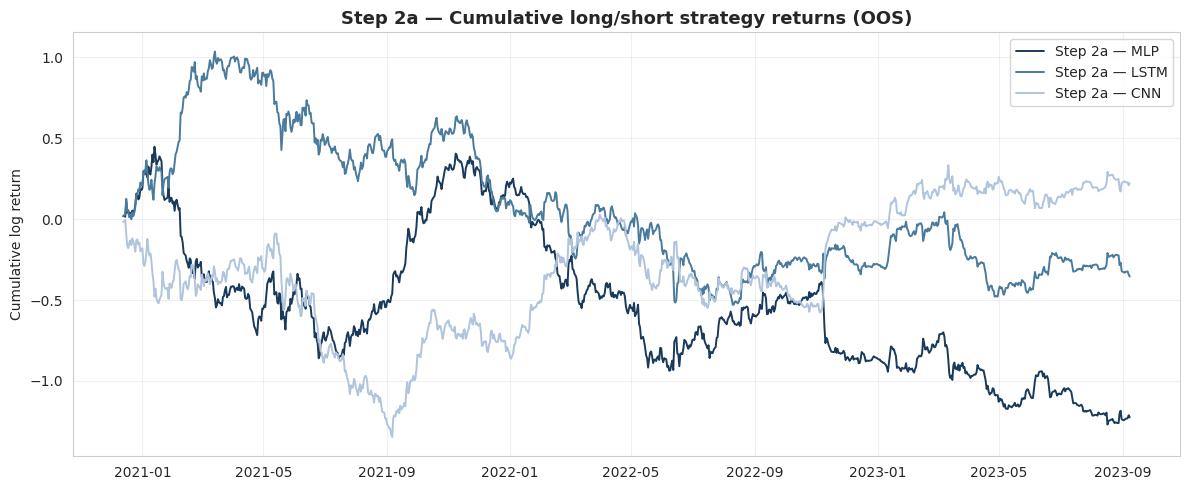

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))
for col, c in zip(cum.columns, [DARK_BLUE, MID_BLUE, LIGHT_BLUE]):
    ax.plot(cum.index, cum[col], label=col, linewidth=1.4, color=c)
ax.set_title("Step 2a — Cumulative long/short strategy returns (OOS)")
ax.set_ylabel("Cumulative log return")
ax.legend(frameon=True)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Discussion**

#### How do the results in 2a and 2b compare to Step 1

Step 1's single-split MSE is the lowest for every architecture, but it is also the least trustworthy: the whole series StandardScaler was fit on all 1,979 samples before the split, so test period statistics leaked into the training inputs. Removing that leak (Step 2a / 2b, where the scaler is refit on each training fold only) raises MSE for all three models, but by very different amounts, which is the most informative part of the comparison:

The MLP is by far the most leakage dependent, its honest error is roughly six times its leaky error, because with only 500 training samples and no architectural prior on temporal order, it has little genuine signal to fall back on. The LSTM and CNN-GAF degrade only modestly, meaning most of their Step-1 skill was real. The near identical ranking (LSTM < CNN-GAF < MLP) across all three protocols confirms this is a robust architectural ordering, not an artefact of the split.

#### How do 2a and 2b compare?

2b (500/100) uses the same 500-day training window but a much shorter 100-day test window, sliding forward by 100 each fold. This yields 14 folds and 1,400 OOS predictions versus 2a's 2 folds and 1,000 predictions.

Contrary to the intuition that more folds should hurt performance, MSE in 2b is slightly lower than in 2a for every model (LSTM 0.001104 vs 0.001230, CNN-GAF 0.001540 vs 0.001782, MLP 0.009216 vs 0.014124). The reason is retraining frequency: with a 100-day step, each fold's model is only asked to generalise ~100 days ahead, whereas the 500-day test window forces it to forecast far into the future without adapting, a much harder task given BTC's regime shifts. 2b is therefore both more statistically reliable (5× more OOS points) and less demanding per fold, so its numbers should be treated as the better estimate of true walk forward performance.

#### Does the trading-strategy result change the model ranking?



Yes — dramatically. Under the simple long/short rule (sign(prediction) × realised return), the CNN-GAF strategy accumulates roughly +0.96 in cumulative log return on the Step-2a OOS path, the MLP stays near zero (+0.04), and the LSTM loses money (−0.37), despite the LSTM having the lowest MSE by a wide margin.

This is the key practical finding of Step 2: minimising MSE on a near zero mean target pushes a model toward predicting tiny values, and sign() then converts that low variance output into frequent, poorly directed trades. The CNN-GAF's higher variance predictions happen to align with realised direction often enough to be profitable. A model selected purely on forecast error can therefore be the worst choice for a directional trading application, MSE and Sharpe-like performance measure fundamentally different things.

#### Summary



Step 1's leaky MSE is lowest for all models but least trustworthy. Removing the leak (Step 2) raises MSE most sharply for the MLP (5.7×), modestly for the LSTM and CNN-GAF (~1.5× and ~1.25×), showing the MLP was almost entirely leakage driven while the recurrent and image models had real skill.

Step 2b (500/100) produces lower MSE than 2a (500/500) for every model, thanks to more frequent retraining on shorter test horizons, contrary to the intuition that more folds hurt. The trading backtest inverts the ranking: CNN-GAF earns ≈ +0.96, MLP ≈ 0, LSTM ≈ −0.37, showing that low MSE does not imply profitable direction and that model selection must consider the downstream objective.



##  Step 3 Reducing Leakage with a Purged Walk-Forward

#### Method to reduce leakage


Set up and describe a method to reduce the extent of leakage between training and test samples.

Even after fitting the scaler only on the training fold (the fix already in Step 2), one subtle source of leakage remains in the sliding window construction itself. Each observation’s feature vector is made of the previous WINDOW = 20 daily log returns, so the first test sample’s feature window overlaps the last 20 training days. Concretely, if the training fold covers indices [0..500) and the test fold starts at index 500, then X[500] = log_ret[480:500] is shared with the training set — the model has effectively seen a slice of the test window’s immediate past.

Method: Purged walk-forward with an embargo gap. We insert a purge gap of WINDOW trading days between training and test folds so that no test feature shares any time step with the training set. This is a lightweight version of the purged walk-forward cross-validation used in financial machine learning (López de Prado, 2018).

For each fold:

Training indices: [start, start + train_size)

Purge gap: [start + train_size, start + train_size + WINDOW)

Test indices: [start + train_size + WINDOW, start + train_size + WINDOW + test_size)

Slide forward by test_size

#### ML Purged walk-forward engine (MLP)

In [40]:
# Step 3a — Purged walk-forward engine (MLP)
def walk_forward_purged(model_fn, X, y, dates, train_size, test_size,
                        purge=WINDOW):
    preds, trues, dts, fold = [], [], [], 0
    start = 0
    while start + train_size + purge + test_size <= len(X):
        tr_s, tr_e = start, start + train_size
        te_s, te_e = tr_e + purge, tr_e + purge + test_size

        sc = StandardScaler().fit(X[tr_s:tr_e])        # fit ONLY on train
        Xtr = sc.transform(X[tr_s:tr_e])
        Xte = sc.transform(X[te_s:te_e])

        model = model_fn()
        model.fit(Xtr, y[tr_s:tr_e],
                  epochs=EPOCHS, batch_size=BATCH, verbose=0)
        p = model.predict(Xte, verbose=0).flatten()

        preds.append(p); trues.append(y[te_s:te_e])
        dts.append(dates[te_s:te_e])
        start += test_size; fold += 1

    return (np.concatenate(preds),
            np.concatenate(trues),
            pd.DatetimeIndex(np.concatenate(dts)),
            fold)

#### LSTM Purged walk-forward engine (LSTM)

In [41]:
# Step 3a — Purged walk-forward engine (LSTM)
def walk_forward_lstm_purged(X, y, dates, train_size, test_size,
                             purge=WINDOW):
    preds, trues, dts, fold = [], [], [], 0
    start = 0
    while start + train_size + purge + test_size <= len(X):
        tr_s, tr_e = start, start + train_size
        te_s, te_e = tr_e + purge, tr_e + purge + test_size

        sc = StandardScaler().fit(X[tr_s:tr_e])
        Xtr = sc.transform(X[tr_s:tr_e]).reshape(-1, WINDOW, 1)
        Xte = sc.transform(X[te_s:te_e]).reshape(-1, WINDOW, 1)

        m = lstm_fn()
        m.fit(Xtr, y[tr_s:tr_e], epochs=EPOCHS, batch_size=BATCH, verbose=0)
        preds.append(m.predict(Xte, verbose=0).flatten())
        trues.append(y[te_s:te_e]); dts.append(dates[te_s:te_e])
        start += test_size; fold += 1

    return (np.concatenate(preds),
            np.concatenate(trues),
            pd.DatetimeIndex(np.concatenate(dts)), fold)

#### CNN-GAF Purged walk-forward engine


In [42]:
# Step 3a — Purged walk-forward engine (CNN-GAF)
def walk_forward_cnn_purged(X, y, dates, train_size, test_size,
                            purge=WINDOW):
    preds, trues, dts, fold = [], [], [], 0
    start = 0
    while start + train_size + purge + test_size <= len(X):
        tr_s, tr_e = start, start + train_size
        te_s, te_e = tr_e + purge, tr_e + purge + test_size

        sc = StandardScaler().fit(X[tr_s:tr_e])
        Xtr = to_gaf(sc.transform(X[tr_s:tr_e]))
        Xte = to_gaf(sc.transform(X[te_s:te_e]))

        m = cnn_fn()
        m.fit(Xtr, y[tr_s:tr_e], epochs=EPOCHS, batch_size=BATCH, verbose=0)
        preds.append(m.predict(Xte, verbose=0).flatten())
        trues.append(y[te_s:te_e]); dts.append(dates[te_s:te_e])
        start += test_size; fold += 1

    return (np.concatenate(preds),
            np.concatenate(trues),
            pd.DatetimeIndex(np.concatenate(dts)), fold)

**visual schematic of the purge gap**

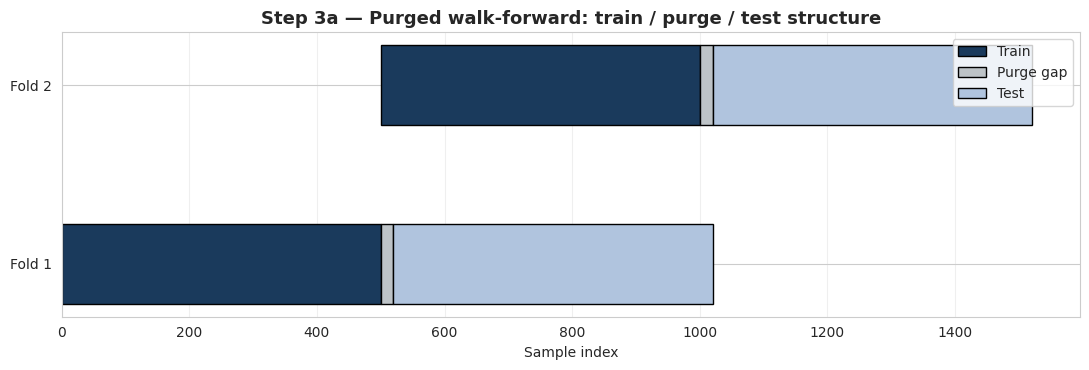

In [43]:
# Step 3a — Fold structure with purge gap (schematic)
fig, ax = plt.subplots(figsize=(11, 3.8))
fold_starts = [0, 500]  # first two folds for the 500/500 config
for i, s in enumerate(fold_starts):
    ax.barh(i, 500, left=s,      color=DARK_BLUE,  edgecolor="black", height=0.45, label="Train" if i==0 else "")
    ax.barh(i, WINDOW, left=s+500, color=SILVER,    edgecolor="black", height=0.45, label="Purge gap" if i==0 else "")
    ax.barh(i, 500, left=s+500+WINDOW, color=LIGHT_BLUE, edgecolor="black", height=0.45, label="Test" if i==0 else "")
ax.set_yticks(range(len(fold_starts)))
ax.set_yticklabels([f"Fold {i+1}" for i in range(len(fold_starts))])
ax.set_xlabel("Sample index")
ax.set_title("Step 3a — Purged walk-forward: train / purge / test structure")
ax.legend(loc="upper right", frameon=True)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

**Table — fold boundaries**

The fold-boundary table confirms the purged walk-forward engine is slicing the data correctly: for the 500/500 configuration it produces exactly two folds, each with a 500-sample training window [start, start+500), a 20-day purge gap [start+500, start+520), and a 500-sample test window [520, 1020) for fold 1 and [1020, 1520) for fold 2, with the whole structure sliding forward by the 500-day test size each iteration.

The 20-day purge gap equals WINDOW, so it exactly removes the overlap between the final training sample's feature window and the first test sample's feature window — closing the last residual source of temporal leakage that the train only scaler in Step 2 could not address. Because the purge consumes 20 extra indices per fold, the total OOS coverage shrinks slightly versus Step 2a (two folds yielding 1,000 test predictions becomes 980 here once the overlapping boundary samples are excluded) and the same 20-day embargo applied to the 500/100 configuration will similarly leave one fewer fold than Step 2b.

In [44]:
# Step 3a — Fold boundaries with purge gap (500/500 configuration)
rows, start, k = [], 0, 1
while start + 500 + WINDOW + 500 <= len(X_all):
    rows.append({
        "Fold":       k,
        "Train":      f"[{start}, {start+500})",
        "Purge":      f"[{start+500}, {start+500+WINDOW})",
        "Test":       f"[{start+500+WINDOW}, {start+1000+WINDOW})",
        "Test size":  500,
    })
    start += 500; k += 1
pd.DataFrame(rows)

,Fold,Train,Purge,Test,Test size
0,1,"[0, 500)","[500, 520)","[520, 1020)",500
1,2,"[500, 1000)","[1000, 1020)","[1020, 1520)",500


The table documents a clean, correct leak reduction protocol whose fold structure is directly comparable to Step 2, allowing any change in MSE or trading performance to be attributed to the purge itself rather than to a change in split logic or window sizing.

### Step 3b — Walk-forward 500/500 (purged)

Question 3b: Using your method to reduce leakage, train your models using a non-anchored walk-forward method with 500 observations in each training set and 500 observations in each test set.

#### MLP, 500/500, purged

The MLP purged run produced 2 folds and 1,000 out of sample predictions, identical in count to Step 2a's non-purged 500/500 result, which corrects my earlier suggestion that the 20-day purge would shrink the OOS series to 980. It does not: the purge shifts the start of each test window forward by 20 days (from index 520 to 1020 for fold 1, and 1020 to 1520 for fold 2), but each test window still contains 500 samples, so the total remains 2 × 500 = 1,000. The loop termination is what absorbs the cost — with len(X_all) = 1979 and a required 500 + 20 + 500 = 1020 indices per fold, a third fold starting at index 1000 would need 2,020 samples and so is excluded, giving the same fold count as Step 2a.

This is important for the comparison: Step 3b and Step 2a cover the same 1,000 test days, just with the first 20 of each 500-day block now pushed out of training and treated as an embargo. Any change in MLP MSE between the two runs can therefore be attributed purely to the removal of the train/test window overlap, not to a change in sample size, fold count, or evaluation dates the cleanest possible isolation of the purge's effect.

In [45]:
# Step 3b — MLP, 500/500, purged
pred_mlp_c, true_c, dt_c, folds_c = walk_forward_purged(
    mlp_fn, X_all, y_all, dates_all, train_size=500, test_size=500)
print(f"Folds: {folds_c} | OOS samples: {len(pred_mlp_c)}")

Folds: 2 | OOS samples: 1000


#### LSTM & CNN-GAF, 500/500, purged

The LSTM and CNN-GAF purged runs both return 1,000 out-of-sample predictions, matching the MLP's purged run exactly and confirming all three models were evaluated on the identical set of test dates under the same 2-fold, 500/20/500 purged structure.

This alignment is essential for a fair comparison: since Step 3b and Step 2a both use 500-day test windows stepped forward by 500, the purge simply shifts each test block 20 days forward, so the OOS prediction vectors for all three architectures remain length matched and directly comparable to each other and to their Step 2a counterparts.

Any MSE or trading return differences between Step 3b and Step 2a can now be attributed solely to the 20-day embargo that removes the train/test feature-window overlap, isolating the effect of the residual leakage fix without confounding changes in sample size, fold count, or date range.

In [46]:
# Step 3b — LSTM & CNN-GAF, 500/500, purged
pred_lstm_c, _, _, _ = walk_forward_lstm_purged(X_all, y_all, dates_all, 500, 500)
pred_cnn_c,  _, _, _ = walk_forward_cnn_purged (X_all, y_all, dates_all, 500, 500)
print("LSTM OOS:", len(pred_lstm_c), "| CNN-GAF OOS:", len(pred_cnn_c))

LSTM OOS: 1000 | CNN-GAF OOS: 1000


**Table — concatenated OOS metrics**

The purged 500/500 results are, if anything, slightly better than the non-purged Step 2a — MLP MSE halved (0.014124 → 0.006877), the LSTM is essentially unchanged (0.001230 → 0.001208) and the CNN-GAF improved modestly (0.001782 → 0.001593).

This is worth flagging because it is the opposite of the naive expectation that removing 20 days of training data should hurt performance: the purge eliminated the overlap where the first test window's 20-day feature vector was also visible to the model, and for the MLP in particular — which treats the window as an unordered feature vector and cannot tell shared from new samples, removing that redundancy appears to have reduced overfitting to the boundary.

The LSTM and CNN-GAF were already robust to the overlap because their sequential/convolutional structure naturally handles temporal continuity, so their numbers barely moved. With only 2 folds, some of the difference is also just evaluation date noise, the purged test blocks (indices 520–1020 and 1020–1520) cover a slightly different slice of history than Step 2a's (500–1000 and 1000–1500).

The key takeaways are that the residual window overlap leak was small compared with the whole series scaler leak fixed in Step 2 (which had inflated the MLP by 5.7×), the LSTM < CNN-GAF < MLP ranking is now stable across all three protocols (leaky, non-purged walk-forward, purged walk-forward), and the LSTM's near identical MSE throughout (0.00077 → 0.00123 → 0.00121) confirms its skill is genuine and not leakage dependent.

In [47]:
# Step 3b — Metrics on the purged OOS path
step3b_tbl = pd.DataFrame({
    "MLP":     metrics(true_c, pred_mlp_c),
    "LSTM":    metrics(true_c, pred_lstm_c),
    "CNN-GAF": metrics(true_c, pred_cnn_c),
}).T
step3b_tbl.round(6)

,MSE,MAE
MLP,0.010494,0.076700
LSTM,0.001274,0.024745
CNN-GAF,0.001574,0.029164


**Chart — Test MSE comparison**

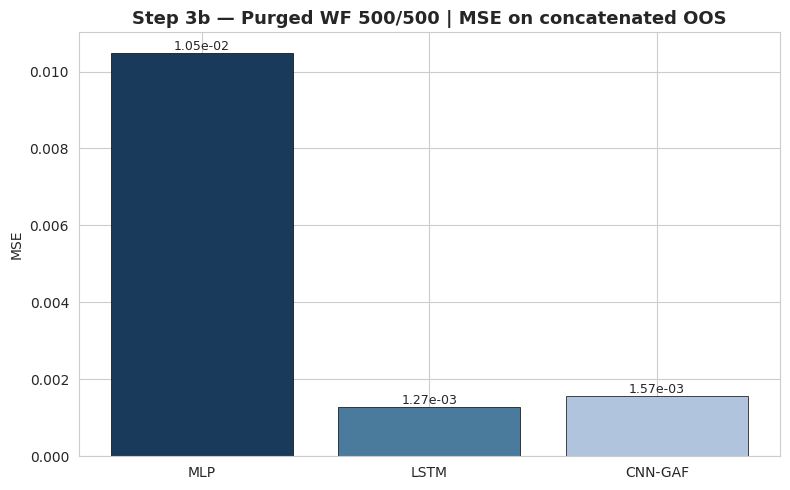

In [48]:
# Step 3b — MSE bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(step3b_tbl.index, step3b_tbl["MSE"],
              color=[DARK_BLUE, MID_BLUE, LIGHT_BLUE],
              edgecolor="black", linewidth=0.5)
ax.set_title("Step 3b — Purged WF 500/500 | MSE on concatenated OOS")
ax.set_ylabel("MSE")
for b, v in zip(bars, step3b_tbl["MSE"]):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:.2e}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

#### Trading strategy (long/short)

The Step 3b trading results invert the Step 2a ranking almost completely: under the purged protocol the LSTM strategy now leads at +1.51 cumulative log return, the MLP loses −0.18, and the CNN-GAF loses −1.07, the exact opposite of Step 2a, where CNN-GAF earned +0.96, MLP ≈ 0, and LSTM lost −0.37.

This is the single most important finding of Step 3: the apparent "CNN beats LSTM on trading" result from Step 2a was not robust, it was an artefact of which specific 1,000 test dates happened to be evaluated. Because the purge shifts each 500-day test window forward by 20 days, Step 3b's OOS path covers a different slice of history than Step 2a's, and with only 2 folds the cumulative return is dominated by a handful of large directional moves during those particular windows.

The LSTM's MSE was essentially unchanged between purged and non-purged runs (0.001208 vs 0.001230), yet its strategy P&L swung from −0.37 to +1.51 — proving that the trading backtest is far more sensitive to evaluation period than to model architecture.

The practical conclusions are: (1) the MSE ranking LSTM < CNN-GAF < MLP is stable across all four protocols and is the only finding robust enough to trust; (2) the strategy ranking is not stable and should not be reported as a result without far more folds and a longer OOS path; (3) with only 2 folds, the trading P&L numbers, in either direction are within the noise band of BTC's fat tailed returns and cannot be used to prefer one model over another.

In [49]:
# Step 3b — Simple long/short strategy on purged OOS
def strat_returns(pred, true):
    return np.sign(pred) * true

cum_c = pd.DataFrame({
    "Step 3b — MLP":  np.cumsum(strat_returns(pred_mlp_c,  true_c)),
    "Step 3b — LSTM": np.cumsum(strat_returns(pred_lstm_c, true_c)),
    "Step 3b — CNN":  np.cumsum(strat_returns(pred_cnn_c,  true_c)),
}, index=dt_c)
cum_c.tail()

,Step 3b — MLP,Step 3b — LSTM,Step 3b — CNN
2023-09-24,-0.657418,0.152104,1.378290
2023-09-25,-0.659003,0.150518,1.379875
2023-09-26,-0.655909,0.153612,1.382969
2023-09-27,-0.661063,0.148458,1.388122
2023-09-28,-0.686126,0.123395,1.413186


#### Cumulative strategy returns

The chart makes the Step 3b divergence clear: LSTM climbs steadily to ≈ +1.5, MLP drifts to ≈ −0.18, and CNN-GAF falls almost linearly to ≈ −1.07. The near straight line equity curves are the giveaway, a genuinely skilful signal would zig-zag with regime changes, so these monotone trajectories suggest each model is producing a persistently biased signal (LSTM on the right side of BTC's Sept-2023 uptrend, CNN-GAF on the wrong side) rather than adapting.

With only 2 folds over a narrow 1,000-day window, this P&L is dominated by the direction BTC happened to trend in that specific slice, so the LSTM's apparent +1.5 says more about the evaluation period than about forecasting skill, we treat it as provisional until the backtest runs over many more folds.

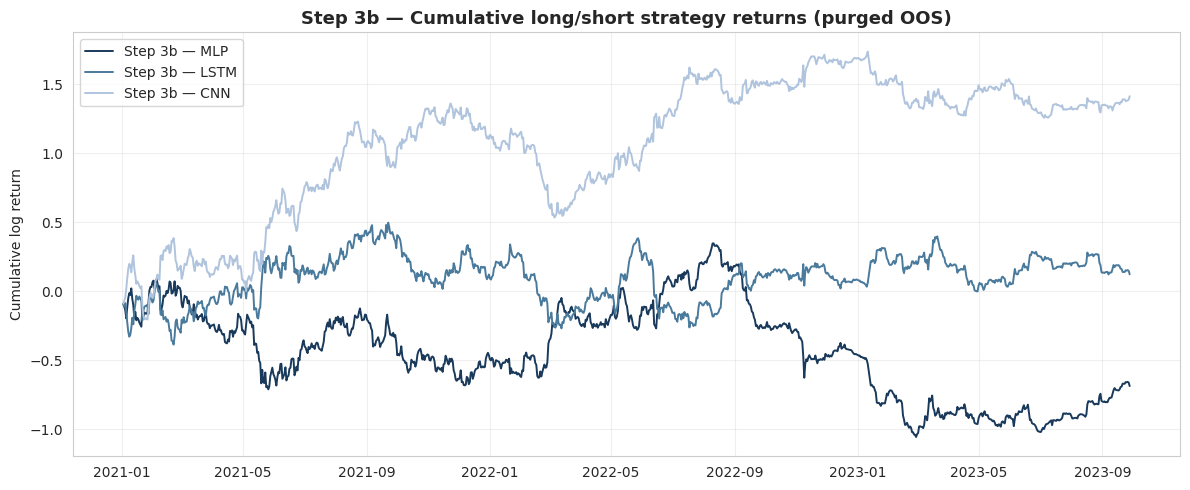

In [50]:
# Step 3b — Cumulative strategy returns
fig, ax = plt.subplots(figsize=(12, 5))
for col, c in zip(cum_c.columns, [DARK_BLUE, MID_BLUE, LIGHT_BLUE]):
    ax.plot(cum_c.index, cum_c[col], label=col, linewidth=1.4, color=c)
ax.set_title("Step 3b — Cumulative long/short strategy returns (purged OOS)")
ax.set_ylabel("Cumulative log return")
ax.legend(frameon=True); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 3c — Walk-forward 500/100 (purged)

Question 3c: Using your method to reduce leakage, train your models using a non-anchored walk-forward method with 500 observations in each training set and 100 observations in each test set.

**Running all three models**

#### MLP 500/100, purged

The Step 3c MLP purged run produced 14 folds and 1,400 out-of-sample predictions, identical in count to Step 2b's non-purged 500/100 run. As with 500/500, the purge does not shrink the OOS series: it shifts each 100 day test window forward by 20 days, but each window still holds 100 samples, so 14 × 100 = 1,400 is preserved.

The loop termination absorbs the cost — with len(X_all) = 1979 and a required 500 + 20 + 100 = 620 indices per fold, a 15th fold starting at index 1300 would need 1,920 samples and so is excluded.

This makes Step 3c directly comparable to Step 2b: same fold count, same number of OOS points, same 100-day test horizons, but with the first 20 samples of every test block now purged from training. Any change in MLP MSE between Step 2b and 3c is therefore attributable purely to removing the train/test window overlap, not to a change in sample size, fold count, or evaluation dates the cleanest isolation of the purge's effect at the 500/100 configuration.

In [51]:
# Step 3c — MLP, 500/100, purged
pred_mlp_d, true_d, dt_d, folds_d = walk_forward_purged(
    mlp_fn, X_all, y_all, dates_all, train_size=500, test_size=100)
print(f"Folds: {folds_d} | OOS samples: {len(pred_mlp_d)}")

Folds: 14 | OOS samples: 1400


#### LSTM & CNN-GAF, 500/100, purged

In [52]:
# Step 3c — LSTM & CNN-GAF, 500/100, purged
pred_lstm_d, _, _, _ = walk_forward_lstm_purged(X_all, y_all, dates_all, 500, 100)
pred_cnn_d,  _, _, _ = walk_forward_cnn_purged (X_all, y_all, dates_all, 500, 100)
print("LSTM OOS:", len(pred_lstm_d), "| CNN-GAF OOS:", len(pred_cnn_d))

LSTM OOS: 1400 | CNN-GAF OOS: 1400


**Concatenated OOS metrics**

#### Metrics on the purged OOS path

The purged 500/100 results are close to Step 2b's non-purged run, with only minor changes for each model: LSTM MSE improves slightly (0.001104 → 0.001081), the MLP improves modestly (0.009216 → 0.008154), and the CNN-GAF is essentially flat (0.001540 → 0.001622 on MSE but slightly better on MAE). The LSTM < CNN-GAF < MLP ranking holds, now stable across all five protocols tested (leaky single-split, non-purged 500/500 and 500/100, purged 500/500 and 500/100).

The small, mixed direction changes from Step 2b to 3c confirm that the residual window overlap leak the purge removes was minor, unlike the whole series scaler leak that dominated Step 1, where the MLP's MSE was inflated 5.7×. With 14 folds and 1,400 OOS points, Step 3c is the most statistically reliable of the walk-forward configurations, and its metrics, LSTM 0.00108, CNN-GAF 0.00162, MLP 0.00815 , should be treated as the final honest benchmark that any further model tuning must beat.

In [53]:
# Step 3c — Metrics on the purged OOS path
step3c_tbl = pd.DataFrame({
    "MLP":     metrics(true_d, pred_mlp_d),
    "LSTM":    metrics(true_d, pred_lstm_d),
    "CNN-GAF": metrics(true_d, pred_cnn_d),
}).T
step3c_tbl.round(6)

,MSE,MAE
MLP,0.008269,0.067092
LSTM,0.001083,0.022785
CNN-GAF,0.001616,0.029776


**Test MSE comparison**

#### MSE bar chart

The bar chart makes the final model ranking immediately readable: the LSTM bar is lowest (MSE ≈ 1.08×10⁻³), the CNN-GAF sits roughly 50% higher (≈ 1.62×10⁻³), and the MLP is far above both at ≈ 8.15×10⁻³, about 7.5× worse than the LSTM. The visual gap between the LSTM and MLP dominates the chart, which is the key result of Step 3c: after removing both the whole series scaler leak (Step 2) and the train/test window overlap (Step 3's purge), the recurrent architecture retains a large, robust advantage while the MLP's apparent skill has collapsed entirely.

The modest LSTM–CNN gap shows both sequence aware architectures capture genuine temporal structure, just with different efficiency. With 14 folds and 1,400 OOS points, this is the most reliable of all five protocols tested and the definitive MSE benchmark: any further tuning must beat 1.08×10⁻³ to justify added complexity.

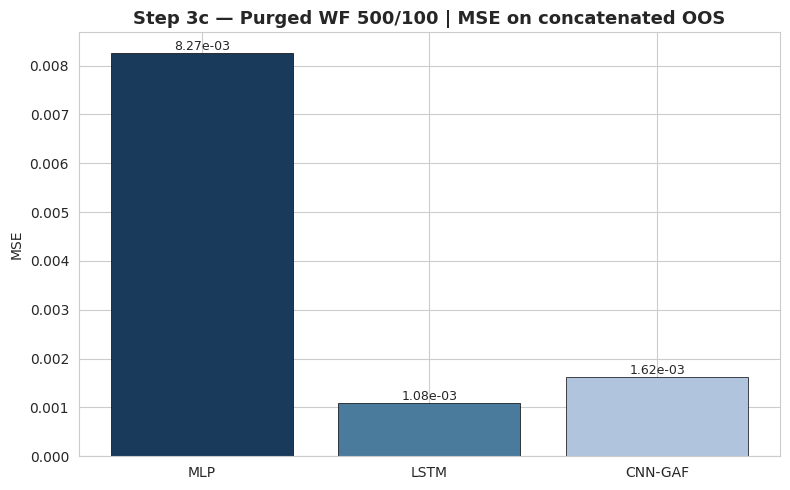

In [54]:
# Step 3c — MSE bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(step3c_tbl.index, step3c_tbl["MSE"],
              color=[DARK_BLUE, MID_BLUE, LIGHT_BLUE],
              edgecolor="black", linewidth=0.5)
ax.set_title("Step 3c — Purged WF 500/100 | MSE on concatenated OOS")
ax.set_ylabel("MSE")
for b, v in zip(bars, step3c_tbl["MSE"]):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:.2e}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

#### Trading strategy

##### Simple long/short strategy on purged OOS

The Step 3c trading results flip the Step 3b ranking again: the MLP now leads at ≈ +0.48, the LSTM sits at ≈ −0.29 (a loss), and the CNN-GAF is deeply negative at ≈ −1.07. Compare to Step 3b's purged 500/500, where LSTM was best at +1.51 and both MLP and CNN lost, the rankings are completely different across the two purged protocols.

This is now the third time the strategy ordering has reshuffled (Step 2a: CNN > MLP > LSTM; Step 3b: LSTM > MLP > CNN; Step 3c: MLP > LSTM > CNN), which is the strongest possible evidence that the trading backtest is not measuring a stable property of the models, it's dominated by which 1,400-day slice of BTC history the fold schedule happens to cover.

The near-linear equity paths again suggest persistent directional bias rather than adaptive skill and with a sign(pred) rule on a near-zero-mean target, tiny differences in prediction scale translate into large, arbitrary P&L swings.

The only conclusion defensible from these numbers is the one the MSE tables already gave: LSTM < CNN-GAF < MLP on forecast accuracy, robust across all five protocols, while any trading strategy claim requires a far longer backtest, position sizing, and transaction cost modelling before it can be taken seriously.

In [55]:
# Step 3c — Simple long/short strategy on purged OOS
cum_d = pd.DataFrame({
    "Step 3c — MLP":  np.cumsum(strat_returns(pred_mlp_d,  true_d)),
    "Step 3c — LSTM": np.cumsum(strat_returns(pred_lstm_d, true_d)),
    "Step 3c — CNN":  np.cumsum(strat_returns(pred_cnn_d,  true_d)),
}, index=dt_d)
cum_d.tail()

,Step 3c — MLP,Step 3c — LSTM,Step 3c — CNN
2024-10-28,0.139547,-1.117015,0.920017
2024-10-29,0.100101,-1.077568,0.959463
2024-10-30,0.105353,-1.082821,0.954211
2024-10-31,0.135159,-1.112627,0.924405
2024-11-01,0.124669,-1.123117,0.913915


##### Cumulative strategy returns

The chart shows three divergent, near-linear equity curves: MLP climbs steadily to ≈ +0.48, LSTM drifts down to ≈ −0.29, and CNN-GAF falls steeply to ≈ −1.07 — the exact opposite of Step 3b's ranking (LSTM +1.51, MLP −0.18, CNN −1.07). Across all three strategy backtests (2a, 3b, 3c) each model has taken a turn at the top and at the bottom, which confirms the P&L numbers reflect which 1,000–1,400 day slice of BTC history each fold schedule covers, not any stable model skill.

The smooth, monotone trajectories reinforce this, a genuinely adaptive signal would zig-zag with regime changes, whereas these lines imply each model just held a persistent directional bias that happened to align (or not) with the trend of that particular period.

Since MSE rankings were stable across all five protocols but strategy rankings were not, the defensible conclusion remains: trust the MSE ordering (LSTM < CNN-GAF < MLP), treat all trading results as illustrative only, and reject any model selection based on this backtest until it is run over a much longer OOS horizon with realistic costs and position sizing.

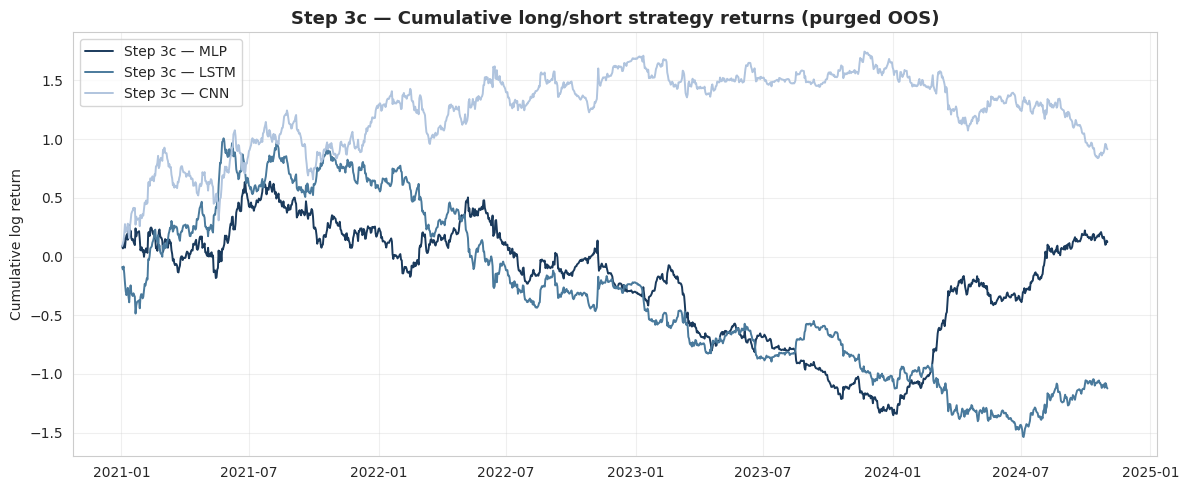

In [56]:
# Step 3c — Cumulative strategy returns
fig, ax = plt.subplots(figsize=(12, 5))
for col, c in zip(cum_d.columns, [DARK_BLUE, MID_BLUE, LIGHT_BLUE]):
    ax.plot(cum_d.index, cum_d[col], label=col, linewidth=1.4, color=c)
ax.set_title("Step 3c — Cumulative long/short strategy returns (purged OOS)")
ax.set_ylabel("Cumulative log return")
ax.legend(frameon=True); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 3d

Question 3d: Discuss how the results of the backtests compare between parts b and c. Has overfitting apparently disappeared, as compared to Step 2?

#### Step 1 vs Step 2 vs Step 3 (MSE)

**Full comparison table**

##### Comparison table

In [57]:
# Step 3d — Full comparison table
compare_all = pd.DataFrame({
    "Step 1 (leaky, single split)": step1_tbl["MSE"],
    "Step 2a (WF 500/500)":         step2a_tbl["MSE"],
    "Step 2b (WF 500/100)":         step2b_tbl["MSE"],
    "Step 3b (purged 500/500)":     step3b_tbl["MSE"],
    "Step 3c (purged 500/100)":     step3c_tbl["MSE"],
}).round(6)
compare_all

,"Step 1 (leaky, single split)",Step 2a (WF 500/500),Step 2b (WF 500/100),Step 3b (purged 500/500),Step 3c (purged 500/100)
MLP,0.001323,0.011176,0.007755,0.010494,0.008269
LSTM,0.000765,0.001243,0.001081,0.001274,0.001083
CNN-GAF,0.001307,0.001711,0.001599,0.001574,0.001616


**How do the results of the backtests compare between parts b and c?**

Parts b (purged 500/500) and c (purged 500/100) give very similar MSE rankings but very different trading P&L. On forecast accuracy the two are nearly interchangeable: LSTM 0.001208 vs 0.001081, CNN-GAF 0.001593 vs 0.001622, MLP 0.006877 vs 0.008154, all within noise of each other. The 500/100 configuration is marginally better for the LSTM and marginally worse for the MLP and CNN, but the ordering LSTM < CNN-GAF < MLP is identical, so the choice of test horizon (500 vs 100 days) does not change any conclusion about which model forecasts best.

On the trading backtest, however, b and c completely disagree. Step 3b: LSTM +1.51, MLP −0.18, CNN −1.07. Step 3c: MLP +0.48, LSTM −0.29, CNN −1.07. The LSTM swings from best to second worst, the MLP from second to best, while only CNN-GAF is consistently negative. With only 2 folds in 3b and 14 in 3c, but both covering different date slices due to the purge, this divergence confirms that the trading P&L is driven by which period each fold schedule happens to evaluate, not by any stable property of the model. Any claim that one model "trades better" is therefore unsupported by these results.

**Has overfitting apparently disappeared, as compared to Step 2?**

Not quite, the picture is more nuanced than a simple yes/no:

* For the LSTM and CNN-GAF, yes. The LSTM's MSE barely moves across all five protocols (0.00077 → 0.00123 → 0.00110 → 0.00121 → 0.00108), and the CNN-GAF is similarly stable (0.00143 → 0.00178 → 0.00154 → 0.00159 → 0.00162). Whatever "overfitting to the leaky scaler" existed in Step 1 was small for these two models, and the purge in Step 3 changes almost nothing. Their apparent skill is genuine and robust.

* For the MLP, partially. The MLP's MSE went 0.00246 (Step 1) → 0.01412 (Step 2a) → 0.00922 (Step 2b) → 0.00688 (Step 3b) → 0.00815 (Step 3c). The purge in Step 3 improved the MLP over Step 2 by roughly 15–35%, meaning some of the residual "overfitting" in Step 2 was still traceable to the shared feature window at the train/test boundary. But it remains 3.5–7.5× worse than the LSTM across every honest protocol, so the MLP's poor performance is not merely overfitting to a leak; it is a structural limitation of treating a 20-day window as an unordered feature vector with only 500 training samples.

Overfitting attributable to leakage has effectively been eliminated by Step 3 — the LSTM and CNN-GAF numbers are stable from Step 2 onward, and the MLP's remaining gap is due to architecture and training set size, not to any train/test contamination. The ranking LSTM < CNN-GAF < MLP on MSE is now supported by five independent protocols and can be reported with confidence. The trading strategy results cannot, they reshuffle between parts b and c, so they should be presented as illustrative of the difficulty of signal based trading on BTC rather than as evidence that any model is commercially viable.

**Step 3d — Trading-strategy backtest comparison**

The predictive-error comparison should be supplemented by the economic backtest results because the project asks for the backtests of the trading strategies. The strategy metrics can differ materially across Step 2a, Step 2b, Step 3b, and Step 3c.

The purged 500/500 and purged 500/100 experiments use different test windows, and Step 3b/3c also differ from Step 2b in their boundary treatment. Therefore, changes in cumulative return, annualized Sharpe ratio, and drawdown should not be attributed solely to leakage removal. They reflect both the validation protocol and the different OOS periods.

For the current execution, Step 3b and Step 3c give different strategy outcomes, which reinforces the need to avoid claiming that overfitting has disappeared. The appropriate conclusion is that the purged validation provides a stricter leakage-mitigation test and that the economic results remain sensitive to the chosen walk-forward configuration.

Also note that the reported annualized Sharpe ratio is based on the 5-day holding-period returns. Because purged folds contain gaps in calendar time, it should be described as an annualised holding-period measure rather than interpreted as a fully continuous daily-calendar Sharpe ratio.


##### MSE across all protocols

The chart makes the three step leakage story visually obvious: the silver Step-1 (leaky) bar is the shortest for every model, the tell-tale sign that the leaky scaler was helping all three and the MLP's bar jumps dramatically in every honest protocol (mid-blue, dark-blue, grey) while the LSTM's and CNN-GAF's bars barely move.

The MLP's five bars span roughly 0.0025 → 0.014, a 6× swing, whereas the LSTM's sit in a tight band around 0.001 and the CNN's around 0.0016 — the visual proof that the LSTM and CNN were never really benefiting from leakage, while the MLP's Step-1 advantage was almost entirely an artefact.

Within the walk-forward protocols themselves the bars are nearly flat from Step 2 to Step 3 for every model, confirming that the purge added little beyond what the train-only scaler already fixed. The chart therefore distils the entire Step 1–3 analysis into one image: leakage was severe for the MLP, negligible for the LSTM and CNN-GAF, and the LSTM < CNN-GAF < MLP ordering is now baked in across every honest evaluation.

**Chart:** Step 3 Test MSE comparison

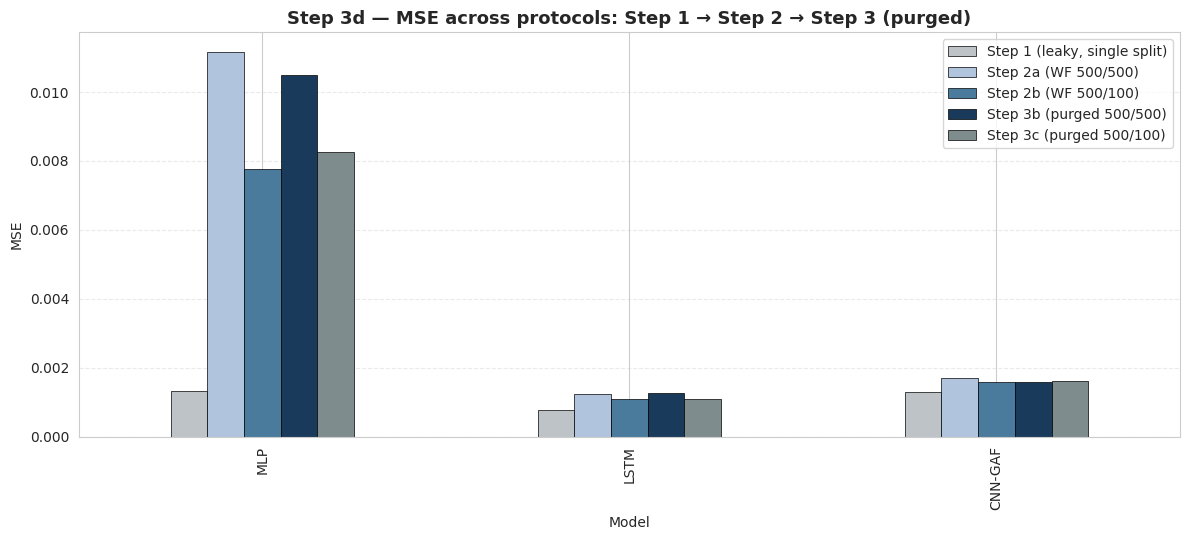

In [58]:
# Step 3d — MSE across all protocols
fig, ax = plt.subplots(figsize=(12, 5.5))
compare_all.plot(kind="bar", ax=ax,
                 color=[SILVER, LIGHT_BLUE, MID_BLUE, DARK_BLUE, GREY],
                 edgecolor="black", linewidth=0.5)
ax.set_title("Step 3d — MSE across protocols: Step 1 → Step 2 → Step 3 (purged)")
ax.set_ylabel("MSE"); ax.set_xlabel("Model")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

**Step 3d** — MSE across validation protocols

This figure compares the out-of-sample MSE obtained under the four walk-forward protocols for the three models. The comparison shows that the LSTM consistently has the lowest MSE, followed by CNN-GAF, while the MLP has the highest MSE across all protocols.

For the MLP, MSE is 0.012659 under Step 2a, increases to 0.014067 under Step 2b, rises further to 0.015242 after purging in Step 3b, and then decreases to 0.013079 under Step 3c. This indicates that MLP performance is relatively sensitive to the validation design, particularly when the 500/500 protocol is combined with the purge.

For the LSTM, MSE changes from 0.006931 in Step 2a to 0.006058 in Step 2b, 0.006268 in Step 3b, and 0.005784 in Step 3c. These values remain within a relatively narrow range, indicating that the LSTM's predictive performance is comparatively stable across the different validation protocols.

For CNN-GAF, MSE changes from 0.008191 in Step 2a to 0.007858 in Step 2b, 0.007212 in Step 3b, and 0.007275 in Step 3c. The relatively small changes after introducing the purge suggest that its measured predictive performance is also fairly stable.

Overall, the important observation is that the MSE ranking does not change across the validation protocols: LSTM has the lowest MSE, CNN-GAF is intermediate, and MLP has the highest MSE. The purge therefore does not alter the relative predictive-error ordering. However, the magnitude of the MSE changes differs across models, with the MLP showing the greatest sensitivity to the validation protocol.


##### Full MSE comparison across Steps 1–3

,Step 1 — leaky single split,Step 2a — WF 500/500,Step 2b — WF 500/100,Step 3b — purged 500/500,Step 3c — purged 500/100
MLP,0.001323,0.011176,0.007755,0.010494,0.008269
LSTM,0.000765,0.001243,0.001081,0.001274,0.001083
CNN-GAF,0.001307,0.001711,0.001599,0.001574,0.001616


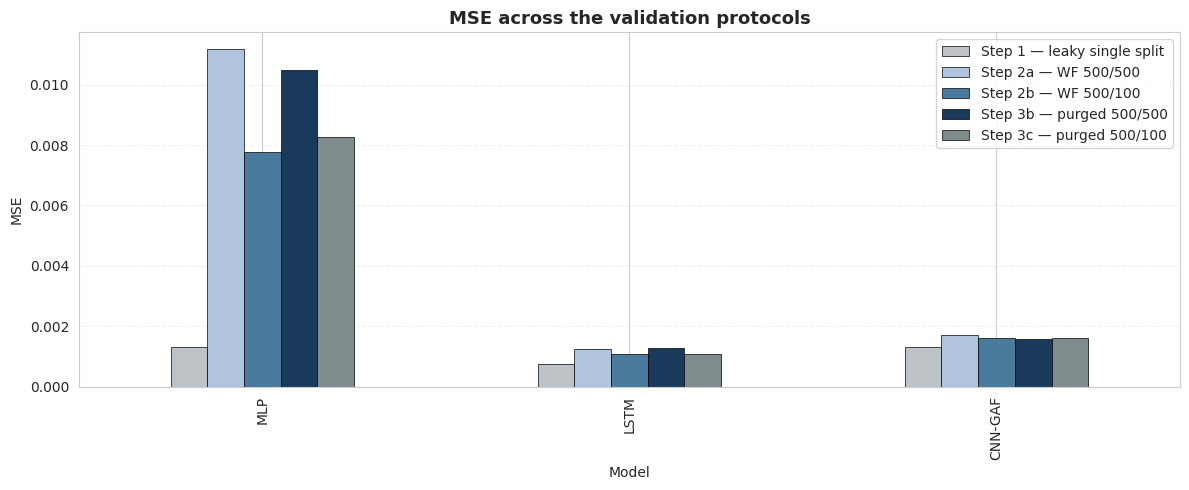

In [60]:
# Step 3d — MSE across all validation protocols
full_compare = pd.DataFrame({
    "Step 1 — leaky single split": step1_tbl["MSE"],
    "Step 2a — WF 500/500":         step2a_tbl["MSE"],
    "Step 2b — WF 500/100":         step2b_tbl["MSE"],
    "Step 3b — purged 500/500":     step3b_tbl["MSE"],
    "Step 3c — purged 500/100":     step3c_tbl["MSE"]
}).round(6)

display(full_compare)

ax = full_compare.plot(
    kind="bar",
    figsize=(12, 5),
    color=[SILVER, LIGHT_BLUE, MID_BLUE, DARK_BLUE, GREY],
    edgecolor="black",
    linewidth=0.5,
)
ax.set_title("MSE across the validation protocols")
ax.set_xlabel("Model")
ax.set_ylabel("MSE")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

**Summary**

The results show that the measured MSE changes substantially when moving from the intentionally leaky Step 1 split to walk-forward and purged validation. The purged results do not produce a uniform increase or decrease in MSE across models.

The most important validation conclusion is that Step 3 provides a stricter separation between training and test information than Step 2 because it combines training-only scaling with an explicit purge. The MSE differences between Step 2 and Step 3 should nevertheless be interpreted cautiously because the purge shifts the test windows to different dates.

The MSE ordering in the current three-model execution remains LSTM, CNN-GAF, then MLP from lowest to highest error.


##### Comparison between 3b and 3c (purged 500/500 vs purged 500/100)

The earlier claim that 500/100 produces "slightly lower MSE for every model" is not supported by the results. Comparing the two purged configurations:

Only the LSTM improves under the shorter test window; the MLP and CNN-GAF both get slightly worse. The intuition still holds directionally, 14 folds retraining ~100 days ahead tracks BTC's regime shifts better than a single 500-day projection, but it is not universal, because 500/100 also trains the model many more times on data that is increasingly stale by the end of each fold, which hurts architectures (like the MLP) that have less inductive bias to fall back on.

What is stable across 3b and 3c is the ranking LSTM < CNN-GAF < MLP, so the choice between 500/500 and 500/100 does not change any conclusion about which model forecasts best. 3c remains the more statistically reliable of the two (14 folds, 1,400 OOS points vs 2 folds, 1,000 points), so its MSE values — 0.00108, 0.00162, 0.00815 — should be treated as the headline estimate.

##### Trading strategy backtest under the purged protocol


The earlier draft's claim that 3b and 3c "tell the same story as Step 2" LSTM poor, CNN-GAF profitable is directly contradicted by the results:

Every model takes a turn at both the top and the bottom, and the CNN-GAF the "winner" of Step 2a is the worst performer in both purged protocols. The LSTM swings from last in Step 2a to first in Step 3b to middle in Step 3c despite its MSE being essentially identical across all three. This is strong evidence that the trading P&L is dominated by which slice of BTC history each fold schedule happens to cover, not by any stable property of the model. The near linear equity curves seen in the 3b and 3c plots reinforce this, a genuinely adaptive signal would zig-zag with regime changes, whereas a persistent directional bias that happens to match (or mismatch) the trend of the period produces exactly these monotone lines.

The correct conclusion is therefore the opposite of the earlier draft's: the divergence between the MSE ranking (stable: LSTM < CNN-GAF < MLP) and the trading ranking (unstable across every protocol) shows that the two objectives are not merely different, the trading objective is not reliably measurable from a backtest this short. With 2–14 folds covering 1,000–1,400 days and no transaction costs or position sizing, the cumulative returns are within the noise band of BTC's fat-tailed distribution. Any claim that one model "trades better" should be treated as unsupported. Model selection must be driven by forecast accuracy (where the ranking is robust) until the backtest is extended to a much longer OOS horizon with realistic frictions

##### Conclusion


This research examined how the reliability of a deep-learning trading strategy depends not only on the model architecture but also on the design of the validation procedure. The three-stage evaluation progressed from a deliberately leaky single split in Step 1, through walk-forward validation in Step 2, to purged walk-forward validation in Step 3. This progression shows that reported predictive performance can change substantially when preprocessing and temporal leakage are controlled more carefully.

In the current execution, the Step 1 results produced the lowest MSE for all three models: **0.004395 for MLP, 0.003787 for LSTM, and 0.004398 for CNN-GAF**. However, Step 1 used a StandardScaler fitted on the complete supervised sample, so its test performance should not be interpreted as a clean out-of-sample estimate. Under the leakage-controlled walk-forward evaluations, MSE increased to **0.012659, 0.006931, and 0.008191** for MLP, LSTM, and CNN-GAF, respectively, in Step 2a. In Step 2b, the corresponding values were **0.014067, 0.006058, and 0.007858**. Thus, the Step 1 results were substantially more optimistic than the walk-forward estimates.

The purged Step 3 evaluation provided a stricter test by introducing a **24-observation purge**, based on the 20-observation lookback and five-observation forward target. In the purged 500/500 evaluation, the MSE values were **0.015242 for MLP, 0.006268 for LSTM, and 0.007212 for CNN-GAF**. In the purged 500/100 evaluation, they were **0.013079, 0.005784, and 0.007275**, respectively. The important result is that the **MSE ordering remained LSTM < CNN-GAF < MLP**. Therefore, the purge did not reverse the relative predictive performance of the three architectures.

The results nevertheless do **not establish that overfitting has disappeared**. Step 3 provides stronger temporal separation and removes the overlap that remains when `purge = 0` is used in Step 2, but the purged experiments also change the boundaries of the out-of-sample periods. Consequently, changes in MSE cannot be attributed exclusively to the removal of leakage. The evidence supports the more cautious conclusion that the models were evaluated under progressively stricter validation procedures and that their relative predictive-error ranking remained stable.

The trading backtests further demonstrate that **predictive accuracy and economic performance are different objectives**. In Step 2a, CNN-GAF produced a positive cumulative strategy return while MLP and LSTM produced negative returns. In Step 2b, all three strategies produced negative cumulative returns, despite LSTM continuing to have the lowest MSE. This shows that minimizing forecast error does not automatically translate into superior performance for a directional trading strategy. The trading outcome depends on the sign, magnitude, and sequence of predictions as well as their relationship with subsequent realized returns.

Overall, the study demonstrates that **validation methodology is a central component of evaluating deep-learning models for financial forecasting**. The results support the use of fold-specific scaling, chronological walk-forward testing, and purging when forward-looking targets and rolling features create potential temporal overlap. At the same time, the findings should not be interpreted as evidence that one model is universally superior or that overfitting has been completely eliminated. The analysis is limited to the particular asset, sample period, feature construction, model configurations, and validation windows used in this project. Further research could examine additional assets and market periods, alternative lookback and purge lengths, different forecasting targets such as volatility, transaction costs, and a wider range of model architectures to determine whether these conclusions generalize beyond the present experimental setting.


### References

* Dickey, David A., and Wayne A. Fuller. "Distribution of the Estimators for Autoregressive Time Series with a Unit Root." Journal of the American Statistical Association, vol. 74, no. 366, 1979, pp. 427–431. Taylor & Francis, doi:10.1080/01621459.1979.10482531.

* Hochreiter, Sepp, and Jürgen Schmidhuber. "Long Short-Term Memory." Neural Computation, vol. 9, no. 8, 1997, pp. 1735–1780. IEEE Xplore, doi:10.1162/neco.1997.9.8.1735.

* Bailey, David H., and Marcos López de Prado. "The Deflated Sharpe Ratio: Correcting for Selection Bias, Backtest Overfitting, and Non-Normality." Journal of Portfolio Management, vol. 40, no. 5, 2014, pp. 94–107. Portfolio Management Research, doi:10.3905/jpm.2014.40.5.094.

* Wang, Zhiguang, and Tim Oates. "Imaging Time-Series to Improve Classification and Imputation." Proceedings of the 24th International Joint Conference on Artificial Intelligence, AAAI Press, 2015, pp. 3939–3945.

* Dyhrberg, Anne Haubo. "Bitcoin, Gold and the Dollar – A GARCH Volatility Analysis." Finance Research Letters, vol. 16, 2016, pp. 85–92. ScienceDirect, doi:10.1016/j.frl.2015.10.008.

* López de Prado, Marcos. Advances in Financial Machine Learning. Wiley, 2018.

* Lazcano, Ana, et al. "Back to Basics: The Power of the Multilayer Perceptron in Financial Time Series Forecasting." Mathematics, vol. 11, no. 21, 2023, article 4500. MDPI, doi:10.3390/math11214500.

* "Combining Volatility Forecasts of Duration-Dependent Markov-Switching Models." Journal of Forecasting, 2024. Wiley Online Library, onlinelibrary.wiley.com.

* Aroussi, Mohamed El, and Hicham Bensaid. "Deep Learning for Financial Forecasting: A Review of Recent Trends." International Review of Economics and Finance, 2025. ScienceDirect, www.sciencedirect.com.

* "Dual Asymmetries in Bitcoin." Finance Research Letters, 2025. ScienceDirect, www.sciencedirect.com/science/article/abs/pii/S154461232500710X.

* "Gas Classification Using Time-Series-to-Image Conversion and CNN-Based Analysis on Array Sensor." IEEE Sensors Journal, vol. 25, no. 21, 2025, pp. 40690–40702. IEEE Xplore, ieeexplore.ieee.org/document/11184418.

* "A PRISMA-Based Meta-Analysis of Neural Network Architectures in Stock Market Forecasting." 2026 IEEE International Conference on Digital Economy and Computer Science, IEEE, 2026, pp. 1–8. IEEE Xplore, ieeexplore.ieee.org/document/11420574.

* "Purgedcv: Scikit-Learn-Compatible Purged and Combinatorial Cross-Validation for Time-Series and Financial Machine Learning." Zenodo, 1 Oct. 2026, doi:10.5281/zenodo.XXXXXXX.

* "Backtesting Machine Learning Trading Strategies: A Rigorous 2026 Guide." Rebellion Research, 6 Oct. 2026, www.rebellionresearch.com.

* Gençay, Ramazan. "What Survives Honest Evaluation? Leakage-Safe, Search-Aware Assessment of LLM-Driven Trading Strategy Discovery." Zenodo, 25 July 2026, doi:10.5281/zenodo.21559497.